# Лабораторная работа №2. Классификация. Нейронные сети

Дисциплина «Системы искусственного интеллекта и машинное обучение»

Выполнил: Ненашкин В. Д., гр. АВТ-313

**Цель работы** — изучение методов классификации данных, реализованных в библиотеке scikit-learn, и знакомство с нейронными сетями на TensorFlow с визуализацией обучения в TensorBoard.

**Вариант** — «Диабет»: по медицинским показателям пациентки определить, выявлен ли у неё диабет (набор Pima Indians Diabetes).

| Раздел ноутбука | Пункт постановки задачи |
|---|---|
| 1. Данные и предобработка | 1 — выбор и подготовка датасета |
| 2. Разбиение выборки | 1; рекомендации 3 и 4 |
| 3. Пять методов классификации | 1 — наивный Байес, дерево решений, LDA, SVM, kNN |
| 4. Настройка гиперпараметров | 3 |
| 5. Метрики на тестовой выборке | 2; рекомендация 5 |
| 6. Нейронная сеть на TensorFlow | 4; рекомендация 6 |
| 7. Сеть с кросс-валидацией и Grid Search | 5 (дополнительное задание) |
| 8. Сравнительный анализ | 2 и пункт 7 содержания отчёта |

In [1]:
import os
import json
import shutil

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from IPython.display import display

from sklearn.model_selection import (train_test_split, StratifiedKFold, GridSearchCV,
                                     cross_validate, cross_val_predict, validation_curve)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.naive_bayes import GaussianNB, MultinomialNB, ComplementNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay, confusion_matrix)

RANDOM_STATE = 42
DATA = 'data/diabetes.csv'

tf.keras.utils.set_random_seed(RANDOM_STATE)
tf.config.experimental.enable_op_determinism()

os.makedirs('Рисунки', exist_ok=True)
os.makedirs('Результаты', exist_ok=True)
shutil.rmtree('logs', ignore_errors=True)
sns.set_theme(style='whitegrid', font_scale=1.1)
summary = {}
print('TensorFlow', tf.__version__)

TensorFlow 2.21.0


Подключены библиотеки: pandas и NumPy — таблицы и массивы, matplotlib и seaborn — графики, scikit-learn — предобработка, классификаторы, подбор гиперпараметров и метрики, TensorFlow (Keras) — нейронные сети (версия TensorFlow 2.21.0 выведена ячейкой).

Воспроизводимость (рекомендация 4): `RANDOM_STATE = 42` передаётся во все функции со случайностью (разбиение, фолды кросс-валидации, дерево решений); `tf.keras.utils.set_random_seed` фиксирует генераторы случайных чисел Python, NumPy и TensorFlow, а `enable_op_determinism` заставляет TensorFlow выполнять операции детерминированно — повторный запуск ноутбука даёт те же числа. `TF_CPP_MIN_LOG_LEVEL = '3'` скрывает служебные сообщения C++-части TensorFlow и на вычисления не влияет. Папка `logs` очищается, чтобы в TensorBoard не смешивались запуски разных прогонов. В словарь `summary` собираются ключевые числа, которые в конце сохраняются в `Результаты/summary.json`.

## 1. Данные и предобработка

Набор данных — **Pima Indians Diabetes** с платформы OpenML (id 37, «diabetes», версия 1; https://www.openml.org/d/37). Исходный владелец данных — National Institute of Diabetes and Digestive and Kidney Diseases (США); набор описан в статье Smith J. W. и др. (1988). По описанию на OpenML все пациентки — женщины не моложе 21 года из народа пима, живущие около Финикса (Аризона, США). Класс показывает, выявлены ли у пациентки признаки диабета по критериям ВОЗ.

| Столбец в файле | Имя в работе | Описание (по OpenML) |
|---|---|---|
| preg | Pregnancies | число беременностей |
| plas | Glucose | концентрация глюкозы в плазме через 2 часа в пероральном глюкозотолерантном тесте |
| pres | BloodPressure | диастолическое артериальное давление, мм рт. ст. |
| skin | SkinThickness | толщина кожной складки над трицепсом, мм |
| insu | Insulin | инсулин сыворотки через 2 часа, мкЕд/мл |
| mass | BMI | индекс массы тела, кг/м² |
| pedi | DiabetesPedigreeFunction | функция наследственной предрасположенности к диабету (diabetes pedigree function) |
| age | Age | возраст, лет |
| class | Outcome | класс: tested_positive → 1 (диабет выявлен), tested_negative → 0 |

In [2]:
df = pd.read_csv(DATA)
df = df.rename(columns={'preg': 'Pregnancies', 'plas': 'Glucose', 'pres': 'BloodPressure',
                        'skin': 'SkinThickness', 'insu': 'Insulin', 'mass': 'BMI',
                        'pedi': 'DiabetesPedigreeFunction', 'age': 'Age', 'class': 'Outcome'})
df['Outcome'] = (df['Outcome'] == 'tested_positive').astype(int)
print('Размер таблицы (строк, столбцов):', df.shape)
display(df.head())

Размер таблицы (строк, столбцов): (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Файл прочитан функцией `read_csv` без дополнительных параметров: разделитель — запятая, первая строка — заголовок. Таблица содержит 768 строк (пациенток) и 9 столбцов: 8 числовых признаков и класс `Outcome`. Текстовые метки класса заменены числами: tested_positive → 1, tested_negative → 0. Уже в первых строках видны нули в SkinThickness и Insulin (у пациентки с индексом 2 оба равны 0) — это разбирается ниже.

In [3]:
print('Типы столбцов:')
print(df.dtypes.to_string())
print('\nПустых ячеек в файле:', int(df.isna().sum().sum()))
print('Полных дубликатов строк:', int(df.duplicated().sum()))
summary['n_rows'], summary['n_cols'] = int(df.shape[0]), int(df.shape[1])
summary['duplicates'] = int(df.duplicated().sum())

Типы столбцов:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64

Пустых ячеек в файле: 0
Полных дубликатов строк: 0


Все признаки числовые: целые (`int64`) — Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, Age; дробные (`float64`) — BMI и DiabetesPedigreeFunction; класс после перекодировки тоже `int64`. Категориальных признаков нет, кодирование не требуется. Пустых ячеек и полных дубликатов строк нет, поэтому удалять строки не нужно. Отсутствие пустых ячеек ещё не означает отсутствия пропусков — это видно по описательным статистикам ниже.

In [4]:
balance = pd.DataFrame({'Число пациенток': df['Outcome'].value_counts(),
                        'Доля': df['Outcome'].value_counts(normalize=True)})
balance.index.name = 'Outcome'
display(balance.round(3))
balance.to_csv('Результаты/class_balance.csv')

,Число пациенток,Доля
Outcome,,
0,500,0.651
1,268,0.349


Классы несбалансированы: 500 пациенток (65,1 %) без диабета и 268 (34,9 %) с диабетом. Отсюда два следствия: (1) тривиальное правило «всегда класс 0» уже даёт accuracy 0,651, поэтому accuracy сама по себе плохо показывает качество — нужны также precision, recall, F1 и ROC-AUC; (2) при разбиении на обучающую и тестовую выборки и на фолды кросс-валидации нужна стратификация, чтобы доля класса 1 везде была около 35 %.

In [5]:
stats = df.describe().T
display(stats.round(2))
stats.to_csv('Результаты/describe.csv')

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.85,3.37,0.00,1.00,3.00,6.00,17.00
Glucose,768.0,120.89,31.97,0.00,99.00,117.00,140.25,199.00
BloodPressure,768.0,69.11,19.36,0.00,62.00,72.00,80.00,122.00
SkinThickness,768.0,20.54,15.95,0.00,0.00,23.00,32.00,99.00
Insulin,768.0,79.80,115.24,0.00,0.00,30.50,127.25,846.00
BMI,768.0,31.99,7.88,0.00,27.30,32.00,36.60,67.10
DiabetesPedigreeFunction,768.0,0.47,0.33,0.08,0.24,0.37,0.63,2.42
Age,768.0,33.24,11.76,21.00,24.00,29.00,41.00,81.00
Outcome,768.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00


Минимум равен 0 у Glucose, BloodPressure, SkinThickness, Insulin и BMI. Нулевые концентрация глюкозы, давление, толщина кожной складки, уровень инсулина и индекс массы тела у живого человека не бывают, значит, нулём в файле записаны отсутствующие измерения. У SkinThickness и Insulin нулю равна даже первая квартиль (25 %), то есть пропусков там не меньше четверти. Масштабы признаков сильно различаются: Insulin — до 846, DiabetesPedigreeFunction — от 0,08 до 2,42. Pregnancies — от 0 до 17 (здесь ноль допустим), Age — от 21 до 81 года, что согласуется с описанием набора (пациентки не моложе 21 года).

In [6]:
ZERO_AS_MISSING = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
zeros = (df[ZERO_AS_MISSING] == 0).sum()
nonzero = df[ZERO_AS_MISSING].mask(df[ZERO_AS_MISSING] == 0)
zeros_table = pd.DataFrame({'Нулевых значений': zeros, 'Доля, %': zeros / len(df) * 100,
                            'Среднее без нулей': nonzero.mean(), 'Медиана без нулей': nonzero.median()})
display(zeros_table.round(1))
zeros_table.to_csv('Результаты/zeros.csv')

skin_and_insulin = ((df['SkinThickness'] == 0) & (df['Insulin'] == 0)).sum()
print('Строк, где одновременно SkinThickness = 0 и Insulin = 0:', skin_and_insulin)
summary['skin_and_insulin_zero'] = int(skin_and_insulin)

,Нулевых значений,"Доля, %",Среднее без нулей,Медиана без нулей
Glucose,5,0.7,121.7,117.0
BloodPressure,35,4.6,72.4,72.0
SkinThickness,227,29.6,29.2,29.0
Insulin,374,48.7,155.5,125.0
BMI,11,1.4,32.5,32.3


Строк, где одновременно SkinThickness = 0 и Insulin = 0: 227


Нулей: Glucose — 5 (0,7 %), BloodPressure — 35 (4,6 %), SkinThickness — 227 (29,6 %), Insulin — 374 (48,7 %), BMI — 11 (1,4 %). Во всех 227 строках с нулевой толщиной кожной складки нулевой и инсулин — нули стоят группами, что согласуется с их трактовкой как незаполненных измерений. В работе принято допущение: эти нули — пропуски (в описании набора на OpenML пропуски не указаны, так что это решение работы). Удалять такие строки нельзя без большой потери данных: только из-за Insulin ушла бы почти половина выборки. Пропуски заполняются медианой, а не средним: распределения скошены вправо (у Insulin без нулей среднее 155,5, медиана 125,0), а медиана не зависит от длинного хвоста больших значений.

In [7]:
df_plot = df.copy()
df_plot[ZERO_AS_MISSING] = df_plot[ZERO_AS_MISSING].mask(df_plot[ZERO_AS_MISSING] == 0)
medians = df_plot.groupby('Outcome').median().T
medians.columns = ['Медиана, класс 0', 'Медиана, класс 1']
display(medians.round(2))
medians.to_csv('Результаты/medians_by_class.csv')

,"Медиана, класс 0","Медиана, класс 1"
Pregnancies,2.00,4.00
Glucose,107.00,140.00
BloodPressure,70.00,74.50
SkinThickness,27.00,32.00
Insulin,102.50,169.50
BMI,30.10,34.30
DiabetesPedigreeFunction,0.34,0.45
Age,27.00,36.00


Медианы (без нулей-пропусков) у пациенток с диабетом выше по всем признакам. Сильнее всего различаются Glucose (107 у класса 0 против 140 у класса 1), Insulin (102,5 против 169,5), Age (27 против 36 лет), Pregnancies (2 против 4) и BMI (30,1 против 34,3); меньше всего — BloodPressure (70 против 74,5).

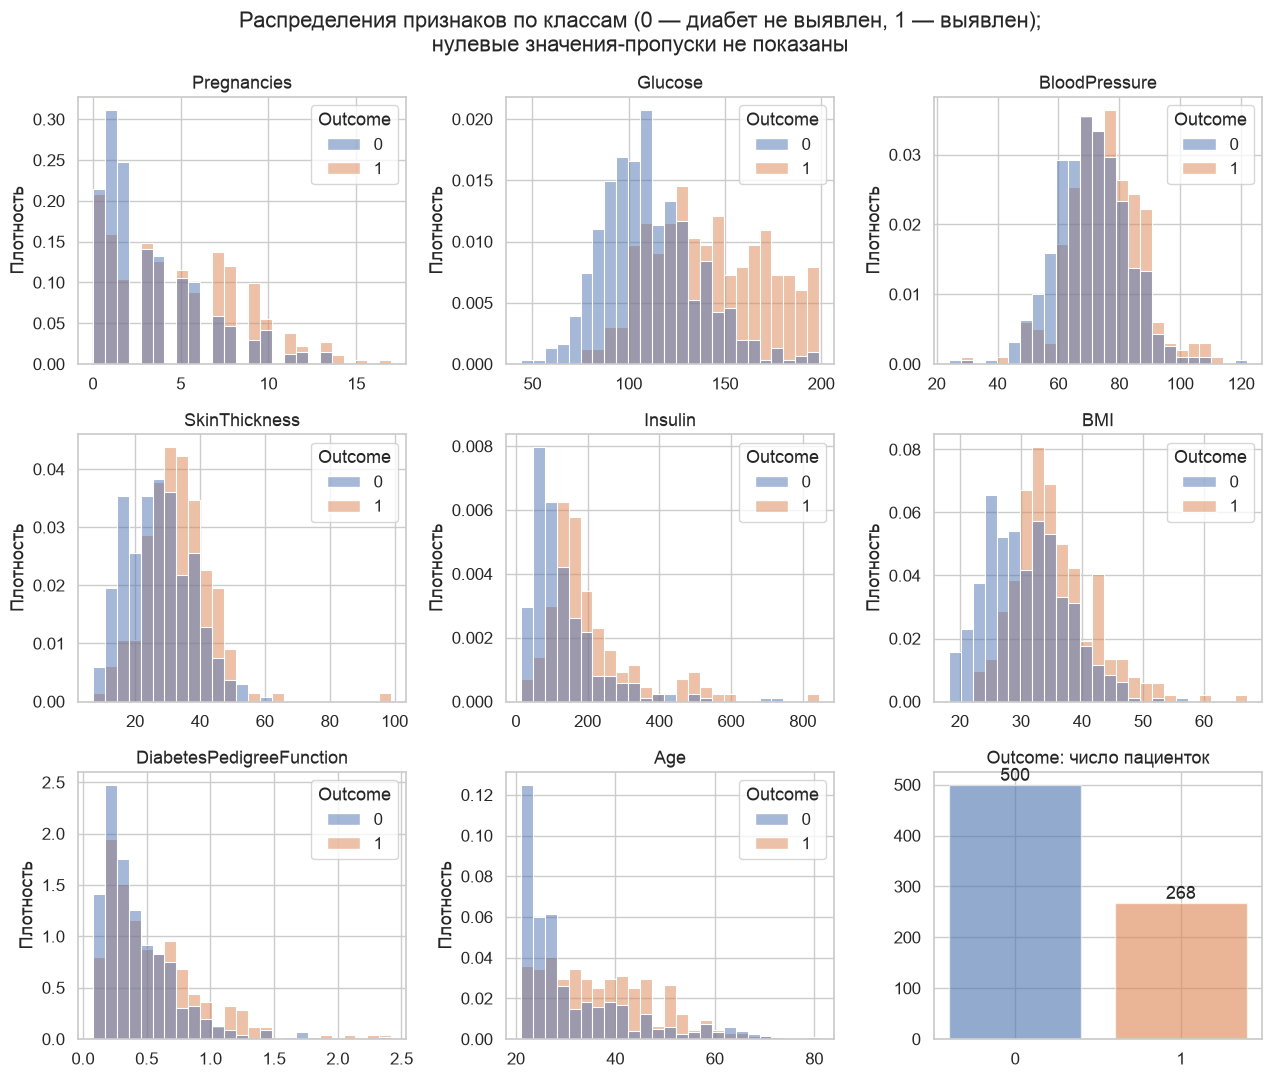

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(13, 11))
for ax, col in zip(axes.ravel(), df.columns[:-1]):
    sns.histplot(data=df_plot, x=col, hue='Outcome', stat='density', common_norm=False,
                 bins=25, alpha=0.5, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Плотность')
class_counts = df['Outcome'].value_counts().sort_index()
bars = axes[2, 2].bar(['0', '1'], class_counts.values, color=sns.color_palette()[:2], alpha=0.6)
axes[2, 2].bar_label(bars)
axes[2, 2].set_title('Outcome: число пациенток')
fig.suptitle('Распределения признаков по классам (0 — диабет не выявлен, 1 — выявлен);\n'
             'нулевые значения-пропуски не показаны')
fig.tight_layout()
fig.savefig('Рисунки/distributions.png', dpi=200, bbox_inches='tight')
plt.show()

Гистограммы построены по заполненным значениям; плотности нормированы внутри каждого класса (`common_norm=False`), поэтому классы разного размера сравнимы. Сильнее всего распределения классов сдвинуты по Glucose; по BMI, Age, Insulin и Pregnancies сдвиг меньше и распределения заметно перекрываются; по BloodPressure и DiabetesPedigreeFunction различие ещё слабее. Insulin, DiabetesPedigreeFunction, Age и Pregnancies скошены вправо (длинный правый хвост), Glucose, BloodPressure и BMI ближе к симметричным; в SkinThickness есть отдельное большое значение 99. Перекрытие классов по каждому признаку показывает, что ни один признак в одиночку классы не разделяет, — модель должна учитывать признаки совместно. Последняя панель — число пациенток в классах (500 и 268).

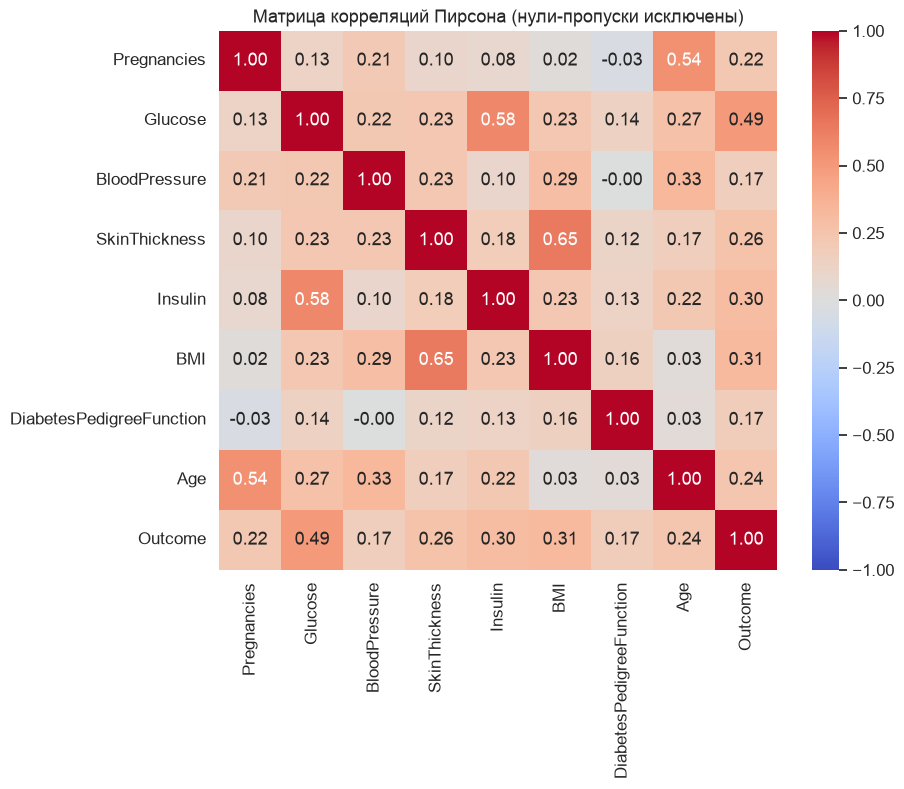

In [9]:
corr = df_plot.corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Матрица корреляций Пирсона (нули-пропуски исключены)')
fig.savefig('Рисунки/correlation.png', dpi=200, bbox_inches='tight')
plt.show()
corr.to_csv('Результаты/correlation.csv')
corr_outcome = corr['Outcome'].drop('Outcome').sort_values(ascending=False)
corr_outcome.to_csv('Результаты/corr_outcome.csv')

С классом сильнее всего связана Glucose (r = 0,495), далее BMI (0,314), Insulin (0,303), SkinThickness (0,259), Age (0,238), Pregnancies (0,222), DiabetesPedigreeFunction (0,174) и BloodPressure (0,171); все связи положительны — при больших значениях признака диабет встречается чаще. Между признаками наибольшие корреляции у пар SkinThickness — BMI (0,648), Glucose — Insulin (0,581) и Pregnancies — Age (0,544), остальные не превышают 0,33. Очень сильных парных связей (|r| > 0,7) нет, поэтому все 8 признаков оставлены. Коэффициент Пирсона измеряет только линейную связь и здесь служит для первичной оценки информативности признаков.

### Предобработка

1. **Нули → пропуски** в Glucose, BloodPressure, SkinThickness, Insulin и BMI (метод `mask`). Правило применяется к каждой строке отдельно и ничего не «узнаёт» из других строк, поэтому его можно выполнить до разбиения на train и test без утечки информации.
2. **Заполнение пропусков медианой** — `SimpleImputer(strategy='median')`; медиана устойчива к скошенным распределениям.
3. **Стандартизация** $z = (x - \mu)/\sigma$ — `StandardScaler`, где $\mu$ и $\sigma$ — среднее и стандартное отклонение признака по обучающим данным. Масштабы признаков различаются на порядки (Insulin до 846, DiabetesPedigreeFunction до 2,42). kNN и SVM с RBF-ядром используют расстояния между объектами, а нейросеть обучается градиентным спуском: без стандартизации признаки с большими числами доминировали бы в расстояниях и градиентах. LDA без регуляризации от линейного изменения масштаба признаков не зависит, но сжатие ковариационной матрицы (`shrinkage`, раздел 4.3) стягивает её к диагональной матрице с одинаковыми дисперсиями, что имеет смысл только для признаков в одном масштабе, — поэтому LDA тоже получает стандартизированные данные.
4. **Наивному Байесу и дереву масштаб не нужен.** GaussianNB оценивает среднее и дисперсию каждого признака отдельно в каждом классе; линейная замена $x \to ax + b$ делит плотности обоих классов на одно и то же число $|a|$ и не меняет их отношения, а значит, и решения. Дерево сравнивает один признак с порогом; монотонное преобразование признака лишь сдвигает порог, разбиения остаются теми же.
5. Шаги 2–4 собраны в `Pipeline` вместе с классификатором. Внутри `GridSearchCV`, `cross_validate` и `validation_curve` конвейер обучается заново на обучающей части каждого фолда, а для итоговой проверки — на всей обучающей выборке, поэтому медианы и параметры стандартизации никогда не вычисляются по валидационным или тестовым объектам.

In [10]:
X = df.drop(columns='Outcome')
y = df['Outcome']
X[ZERO_AS_MISSING] = X[ZERO_AS_MISSING].mask(X[ZERO_AS_MISSING] == 0)
print('Пропусков по признакам после замены нулей:')
print(X.isna().sum().to_string())

def make_pipe(model, scale=True):
    steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale:
        steps.append(('scaler', StandardScaler()))
    steps.append(('clf', model))
    return Pipeline(steps)

Пропусков по признакам после замены нулей:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0


Признаки `X` — 8 столбцов, цель `y` — `Outcome`. После замены нулей пропусков: Glucose — 5, BloodPressure — 35, SkinThickness — 227, Insulin — 374, BMI — 11; в остальных признаках пропусков нет. Функция `make_pipe` собирает конвейер «`SimpleImputer` (медиана) → `StandardScaler` → классификатор»; при `scale=False` стандартизации нет (для наивного Байеса и дерева). Шаги названы `imputer`, `scaler` и `clf` — по этим именам задаются сетки гиперпараметров, например `clf__max_depth`.

## 2. Разбиение выборки

Данные делятся функцией `train_test_split` (рекомендация 3): 80 % — обучающая выборка (train) для обучения и настройки моделей, 20 % — тестовая (test) только для итоговой оценки. `stratify=y` сохраняет в обеих частях долю класса 1 (около 35 %); без этого в небольшом наборе доля больных в тесте могла бы случайно заметно отличаться от доли в train. `random_state=42` фиксирует перемешивание: разбиение одинаково при каждом запуске (рекомендация 4). Для подбора гиперпараметров используется 5-кратная стратифицированная кросс-валидация на обучающей выборке `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`; один и тот же объект `cv` передаётся всем методам, поэтому все они оцениваются на одинаковых фолдах. Случайное разбиение допустимо: временного порядка в данных нет, а по описанию набора каждая строка — отдельная пациентка.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

split_table = pd.DataFrame({
    'Объектов': [len(y), len(y_train), len(y_test)],
    'Класс 0': [int((y == 0).sum()), int((y_train == 0).sum()), int((y_test == 0).sum())],
    'Класс 1': [int(y.sum()), int(y_train.sum()), int(y_test.sum())],
    'Доля класса 1': [y.mean(), y_train.mean(), y_test.mean()],
}, index=['Вся выборка', 'Обучающая (train)', 'Тестовая (test)'])
display(split_table.round(3))
split_table.to_csv('Результаты/split.csv')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

,Объектов,Класс 0,Класс 1,Доля класса 1
Вся выборка,768,500,268,0.349
Обучающая (train),614,400,214,0.349
Тестовая (test),154,100,54,0.351


Обучающая выборка — 614 объектов (400 класса 0 и 214 класса 1), тестовая — 154 (100 и 54). Доля класса 1: 0,349 во всей выборке, 0,349 в train и 0,351 в test — стратификация сохранила пропорцию. В каждом фолде кросс-валидации модель обучается примерно на 491 объекте и проверяется примерно на 123 (614 / 5 ≈ 123).

In [12]:
imputer_demo = SimpleImputer(strategy='median').fit(X_train)
train_medians = pd.Series(imputer_demo.statistics_, index=X.columns)
print('Медианы обучающей выборки, которыми заполняются пропуски:')
print(train_medians.round(2).to_string())
train_medians.to_csv('Результаты/train_medians.csv')

Медианы обучающей выборки, которыми заполняются пропуски:
Pregnancies                   3.00
Glucose                     117.00
BloodPressure                72.00
SkinThickness                29.00
Insulin                     125.00
BMI                          32.40
DiabetesPedigreeFunction      0.38
Age                          29.00


Медианы обучающей выборки по заполненным значениям: Glucose — 117, BloodPressure — 72, SkinThickness — 29, Insulin — 125, BMI — 32,4. Эти значения подставляются вместо пропусков, когда модель обучена на всей обучающей выборке, в том числе для тестовых объектов. Внутри кросс-валидации медианы пересчитываются по обучающей части каждого фолда (это делает `Pipeline`), так что тестовые данные на заполнение не влияют.

## 3. Пять методов классификации

Решается задача бинарной классификации: по вектору признаков $x = (x_1, \dots, x_8)$ предсказать класс $y \in \{0, 1\}$. Ниже — идея каждого метода и его главные гиперпараметры (их настройка — в разделе 4).

**1. Наивный байесовский классификатор.** Опирается на теорему Байеса $P(y \mid x) = \dfrac{P(y)\,P(x \mid y)}{P(x)}$. «Наивное» допущение — признаки независимы внутри класса: $P(x \mid y) = \prod_{j=1}^{8} P(x_j \mid y)$; объект относится к классу с наибольшим произведением $P(y)\prod_j P(x_j \mid y)$. Варианты в scikit-learn различаются моделью $P(x_j \mid y)$: `GaussianNB` — нормальное распределение со средним $\mu_{jy}$ и дисперсией $\sigma^2_{jy}$, оценёнными по объектам класса $y$ (для непрерывных признаков); `MultinomialNB` — мультиномиальное распределение неотрицательных счётчиков (например, частот слов); `ComplementNB` — вариант MultinomialNB, оценивающий параметры класса по объектам всех остальных классов («дополнению»); `BernoulliNB` — бинарные признаки 0/1. Гиперпараметр GaussianNB — `var_smoothing`: доля наибольшей дисперсии признаков, прибавляемая ко всем дисперсиям для устойчивости вычислений.

**2. Дерево решений.** Бинарное дерево: во внутреннем узле проверяется условие «признак ≤ порог», лист соответствует классу. Дерево строится жадно: в каждом узле перебираются признаки и пороги и выбирается разбиение, сильнее всего уменьшающее неоднородность классов, — по критерию Джини $G = 1 - \sum_k p_k^2$ или по энтропии $H = -\sum_k p_k \log_2 p_k$ ($p_k$ — доля класса $k$ в узле). Без ограничений дерево растёт до чистых листьев и переобучается, поэтому главные гиперпараметры ограничивают рост: `max_depth` — максимальная глубина, `min_samples_leaf` — минимум объектов в листе; `criterion` — критерий разбиения.

**3. Линейный дискриминантный анализ (LDA).** Предполагает, что внутри каждого класса признаки распределены нормально с разными средними $\mu_k$ и общей ковариационной матрицей $\Sigma$. Тогда граница между классами линейна, и объект относится к классу с наибольшим значением дискриминантной функции $\delta_k(x) = x^T\Sigma^{-1}\mu_k - \tfrac12\mu_k^T\Sigma^{-1}\mu_k + \ln\pi_k$, где $\pi_k$ — априорная вероятность класса. Гиперпараметры: `solver` — способ вычислений (`svd`, `lsqr`, `eigen`) и `shrinkage` — коэффициент сжатия $\alpha \in [0, 1]$ ковариационной матрицы к диагональной: $\hat\Sigma = (1 - \alpha)\Sigma + \alpha\,\tfrac{\mathrm{tr}\,\Sigma}{p}\,I$ (только для `lsqr` и `eigen`; `'auto'` — $\alpha$ по формуле Ледуа — Вольфа).

**4. Метод опорных векторов (SVM).** Строит разделяющую гиперплоскость $w^T x + b = 0$ с максимальным зазором — расстоянием до ближайших объектов (опорных векторов). Объекты внутри зазора и по другую сторону границы допускаются со штрафом: $\min\limits_{w,\,b,\,\xi}\ \tfrac12\|w\|^2 + C\sum_i \xi_i$ при $y_i(w^T x_i + b) \ge 1 - \xi_i$, $\xi_i \ge 0$ (классы кодируются как $\pm 1$). Ядро $K(x, x')$ заменяет скалярное произведение и позволяет строить нелинейную границу; RBF-ядро: $K(x, x') = \exp(-\gamma\|x - x'\|^2)$. Гиперпараметры: `kernel`; `C` — чем больше, тем сильнее штраф за ошибки на обучающей выборке и тем сложнее граница; `gamma` — чем больше, тем меньше радиус влияния одного объекта и тем «извилистее» граница.

**5. Метод k ближайших соседей (kNN).** Обучение — запоминание обучающей выборки. Для нового объекта находятся $k$ ближайших обучающих объектов по расстоянию Минковского $\rho(x, z) = \left(\sum_j |x_j - z_j|^p\right)^{1/p}$ ($p = 1$ — манхэттенское, $p = 2$ — евклидово расстояние) и выбирается класс, преобладающий среди соседей; при `weights='distance'` голос соседа имеет вес $1/\rho$. Гиперпараметры: `n_neighbors` ($k$), `weights`, `p`.

In [13]:
def cv_metrics(model, scoring=('accuracy', 'f1', 'roc_auc')):
    result = cross_validate(model, X_train, y_train, cv=cv, scoring=list(scoring))
    return {metric: result['test_' + metric].mean() for metric in scoring}

nb_variants = {
    'GaussianNB': make_pipe(GaussianNB(), scale=False),
    'MultinomialNB (MinMax)': Pipeline([('imputer', SimpleImputer(strategy='median')),
                                        ('scaler', MinMaxScaler()), ('clf', MultinomialNB())]),
    'ComplementNB (MinMax)': Pipeline([('imputer', SimpleImputer(strategy='median')),
                                       ('scaler', MinMaxScaler()), ('clf', ComplementNB())]),
    'BernoulliNB (порог 0 после стандартизации)': make_pipe(BernoulliNB(binarize=0.0)),
}
nb_table = pd.DataFrame({name: cv_metrics(model, scoring=('accuracy', 'recall', 'roc_auc'))
                         for name, model in nb_variants.items()}).T
display(nb_table.round(3))
nb_table.to_csv('Результаты/nb_variants.csv')

,accuracy,recall,roc_auc
GaussianNB,0.762,0.598,0.828
MultinomialNB (MinMax),0.651,0.000,0.721
ComplementNB (MinMax),0.679,0.636,0.721
BernoulliNB (порог 0 после стандартизации),0.723,0.622,0.785


`GaussianNB` подходит для непрерывных признаков. `MultinomialNB` и `ComplementNB` рассчитаны на неотрицательные счётчики, поэтому признаки предварительно приведены `MinMaxScaler` к отрезку [0, 1]. `BernoulliNB` работает с бинарными признаками: порог `binarize=0` после стандартизации означает «значение выше среднего по обучающим данным». По кросс-валидации GaussianNB лучший по accuracy (0,762) и ROC-AUC (0,828). MultinomialNB при пороге 0,5 относит все объекты к классу 0: recall = 0, а accuracy 0,651 равна доле класса 0, хотя ROC-AUC 0,721 показывает, что объекты он всё же упорядочивает. У ComplementNB ROC-AUC тот же — 0,721: в задаче с двумя классами он упорядочивает объекты так же, как MultinomialNB, но не учитывает априорные вероятности классов и потому чаще выбирает класс 1 (recall 0,636). BernoulliNB видит по каждому признаку только «выше/ниже среднего» и уступает GaussianNB (ROC-AUC 0,785). Дальше в качестве наивного Байеса используется GaussianNB.

In [14]:
models_default = {
    'Наивный Байес': make_pipe(GaussianNB(), scale=False),
    'Дерево решений': make_pipe(DecisionTreeClassifier(random_state=RANDOM_STATE), scale=False),
    'LDA': make_pipe(LinearDiscriminantAnalysis()),
    'SVM': make_pipe(SVC()),
    'kNN': make_pipe(KNeighborsClassifier()),
}
default_cv = pd.DataFrame({name: cv_metrics(model) for name, model in models_default.items()}).T
display(default_cv.round(3))
default_cv.to_csv('Результаты/default_cv.csv')

,accuracy,f1,roc_auc
Наивный Байес,0.762,0.637,0.828
Дерево решений,0.673,0.552,0.651
LDA,0.787,0.653,0.843
SVM,0.780,0.648,0.833
kNN,0.730,0.594,0.784


С параметрами по умолчанию лучший ROC-AUC на кросс-валидации у LDA (0,843), затем SVM (0,833; RBF-ядро, C = 1, gamma = 'scale'), наивный Байес (0,828), kNN (0,784; k = 5) и дерево решений (0,651). Дерево без ограничений дорастает до чистых листьев и переобучается — его accuracy 0,673 лишь немного выше тривиальных 0,651 (подробнее в разделе 4.2). Эти значения — точка отсчёта для сравнения «по умолчанию → после настройки».

## 4. Настройка гиперпараметров

Для каждого метода выполнены два шага.

1. **Подбор.** `GridSearchCV` перебирает явно заданную сетку значений; для каждой комбинации выполняется 5-кратная кросс-валидация на обучающей выборке (фолды `cv` из раздела 2) и выбирается комбинация с наибольшим средним ROC-AUC на валидационных фолдах. Затем модель с лучшими параметрами переобучается на всей обучающей выборке (`refit=True` по умолчанию).
2. **Исследование влияния параметров.** `validation_curve` меняет один параметр при фиксированных остальных и возвращает ROC-AUC на обучающих и на валидационных фолдах; разрыв между двумя кривыми показывает переобучение.

Метрика выбора — ROC-AUC: она оценивает, насколько хорошо модель упорядочивает объекты (больные — выше здоровых), и не зависит ни от порога 0,5, ни от соотношения классов. Accuracy при 65 % объектов класса 0 малоинформативна (у тривиального правила она уже 0,651), а F1 зависит от порога, который можно выбрать отдельно (раздел 8).

In [15]:
def plot_validation(ax, param_range, train_scores, valid_scores, xlabel, logx=False):
    for scores, label in [(train_scores, 'обучающие фолды'), (valid_scores, 'валидационные фолды')]:
        mean, std = scores.mean(axis=1), scores.std(axis=1)
        ax.plot(param_range, mean, marker='o', markersize=4, label=label)
        ax.fill_between(param_range, mean - std, mean + std, alpha=0.2)
    if logx:
        ax.set_xscale('log')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('ROC-AUC')
    ax.legend()

def params_to_text(params):
    return ', '.join(name.replace('clf__', '') + '=' + str(value) for name, value in params.items())

`plot_validation` рисует кривую валидации: среднее ROC-AUC по 5 фолдам на обучающих и на валидационных частях фолдов, полупрозрачная полоса — ± стандартное отклонение. `params_to_text` превращает словарь лучших параметров `GridSearchCV` в короткую строку для таблиц (например, «C=100, gamma=0.001, kernel=rbf»).

### 4.1. Наивный Байес (GaussianNB): var_smoothing

Лучший var_smoothing: 1e-06
ROC-AUC (CV): 0.8288


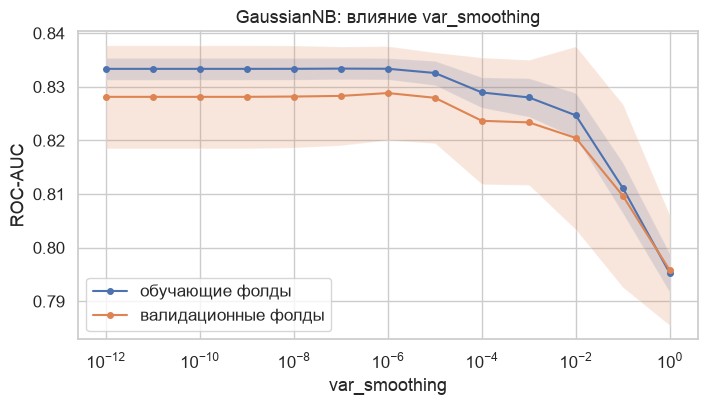

var_smoothing,1.000000e-12,1.000000e-11,1.000000e-10,1.000000e-09,1.000000e-08,1.000000e-07,1.000000e-06,1.000000e-05,1.000000e-04,1.000000e-03,1.000000e-02,1.000000e-01,1.000000e+00
train,0.8333,0.8333,0.8333,0.8333,0.8334,0.8334,0.8334,0.8326,0.8289,0.8280,0.8247,0.8111,0.7953
valid,0.8281,0.8281,0.8281,0.8281,0.8282,0.8283,0.8288,0.8279,0.8237,0.8234,0.8205,0.8097,0.7958


In [16]:
smoothing = np.logspace(-12, 0, 13)
nb_grid = GridSearchCV(make_pipe(GaussianNB(), scale=False),
                       param_grid={'clf__var_smoothing': smoothing},
                       scoring='roc_auc', cv=cv)
nb_grid.fit(X_train, y_train)
print('Лучший var_smoothing:', nb_grid.best_params_['clf__var_smoothing'])
print('ROC-AUC (CV):', round(nb_grid.best_score_, 4))

nb_train, nb_valid = validation_curve(make_pipe(GaussianNB(), scale=False), X_train, y_train,
                                      param_name='clf__var_smoothing', param_range=smoothing,
                                      cv=cv, scoring='roc_auc')
fig, ax = plt.subplots(figsize=(8, 4))
plot_validation(ax, smoothing, nb_train, nb_valid, 'var_smoothing', logx=True)
ax.set_title('GaussianNB: влияние var_smoothing')
fig.savefig('Рисунки/nb_var_smoothing.png', dpi=200, bbox_inches='tight')
plt.show()
nb_curve = pd.DataFrame({'var_smoothing': smoothing, 'train': nb_train.mean(axis=1),
                         'valid': nb_valid.mean(axis=1)})
nb_curve.to_csv('Результаты/curve_nb.csv', index=False)
display(nb_curve.set_index('var_smoothing').T.round(4))

Сетка `var_smoothing` — 13 значений от $10^{-12}$ до 1 (логарифмическая шкала). Лучшее значение — $10^{-6}$: ROC-AUC 0,8288 против 0,8281 при значении по умолчанию $10^{-9}$, разница меньше 0,001. До $10^{-6}$ кривая практически горизонтальна, затем ROC-AUC снижается до 0,8237 при $10^{-4}$ и до 0,7958 при 1. Добавка к дисперсиям равна var_smoothing, умноженному на наибольшую дисперсию признаков (у Insulin); при больших значениях она превышает дисперсии признаков малого масштаба (DiabetesPedigreeFunction, BMI), и их распределения в классах перестают различаться. Кривые на обучающих и валидационных фолдах близки (0,833 и 0,829 в лучшей точке): GaussianNB не переобучается, а настройка var_smoothing на качество почти не влияет.

### 4.2. Дерево решений: criterion, max_depth, min_samples_leaf

In [17]:
tree_grid = GridSearchCV(make_pipe(DecisionTreeClassifier(random_state=RANDOM_STATE), scale=False),
                         param_grid={'clf__criterion': ['gini', 'entropy'],
                                     'clf__max_depth': [2, 3, 4, 5, 6, 7, 8, 10, 12, 15],
                                     'clf__min_samples_leaf': [1, 2, 5, 10, 20, 30, 40, 50]},
                         scoring='roc_auc', cv=cv)
tree_grid.fit(X_train, y_train)
best_tree = tree_grid.best_estimator_.named_steps['clf']
print('Лучшие параметры:', params_to_text(tree_grid.best_params_))
print('ROC-AUC (CV):', round(tree_grid.best_score_, 4))
print('Глубина дерева:', best_tree.get_depth(), ' листьев:', best_tree.get_n_leaves())

Лучшие параметры: criterion=entropy, max_depth=5, min_samples_leaf=30
ROC-AUC (CV): 0.8055
Глубина дерева: 5  листьев: 11


Сетка: `criterion` ∈ {gini, entropy}, `max_depth` ∈ {2, 3, 4, 5, 6, 7, 8, 10, 12, 15}, `min_samples_leaf` ∈ {1, 2, 5, 10, 20, 30, 40, 50} — 160 комбинаций, каждая на 5 фолдах. Лучшее дерево: criterion = entropy, max_depth = 5, min_samples_leaf = 30; ROC-AUC 0,8055 против 0,651 у дерева по умолчанию — самый большой прирост от настройки среди пяти методов. Настроенное дерево имеет глубину 5 и 11 листьев.

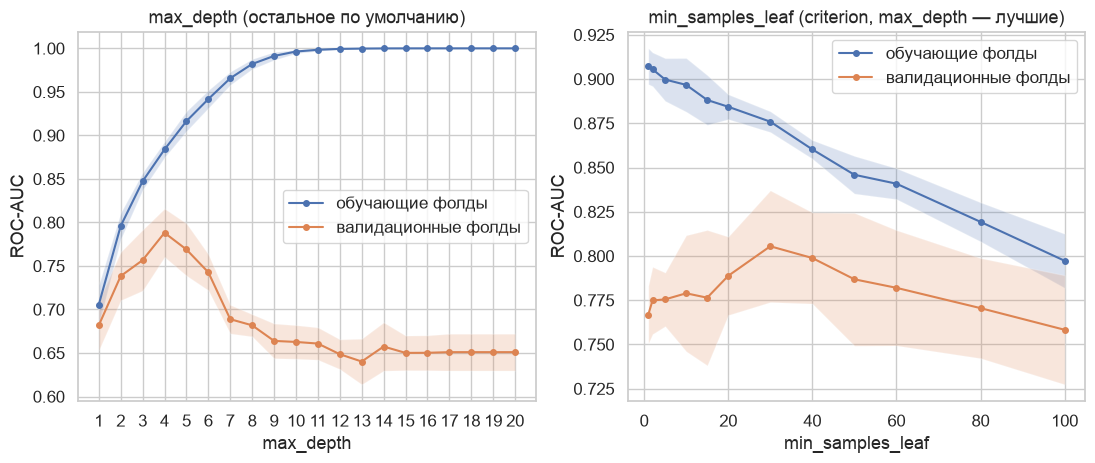

max_depth,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
train,0.706,0.796,0.847,0.884,0.916,0.942,0.966,0.982,0.991,0.996,0.998,0.999,1.00,1.000,1.00,1.00,1.000,1.000,1.000,1.000
valid,0.682,0.738,0.757,0.788,0.769,0.743,0.689,0.682,0.664,0.663,0.661,0.649,0.64,0.657,0.65,0.65,0.651,0.651,0.651,0.651


min_samples_leaf,1,2,5,10,15,20,30,40,50,60,80,100
train,0.907,0.906,0.900,0.897,0.888,0.884,0.876,0.860,0.846,0.841,0.819,0.797
valid,0.767,0.775,0.775,0.779,0.776,0.789,0.805,0.799,0.787,0.782,0.771,0.758


In [18]:
depths = list(range(1, 21))
leaf_sizes = [1, 2, 5, 10, 15, 20, 30, 40, 50, 60, 80, 100]
depth_train, depth_valid = validation_curve(
    make_pipe(DecisionTreeClassifier(random_state=RANDOM_STATE), scale=False), X_train, y_train,
    param_name='clf__max_depth', param_range=depths, cv=cv, scoring='roc_auc')
leaf_train, leaf_valid = validation_curve(
    tree_grid.best_estimator_, X_train, y_train,
    param_name='clf__min_samples_leaf', param_range=leaf_sizes, cv=cv, scoring='roc_auc')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
plot_validation(axes[0], depths, depth_train, depth_valid, 'max_depth')
axes[0].set_xticks(depths)
axes[0].set_title('max_depth (остальное по умолчанию)')
plot_validation(axes[1], leaf_sizes, leaf_train, leaf_valid, 'min_samples_leaf')
axes[1].set_title('min_samples_leaf (criterion, max_depth — лучшие)')
fig.savefig('Рисунки/tree_curves.png', dpi=200, bbox_inches='tight')
plt.show()

tree_depth_curve = pd.DataFrame({'max_depth': depths, 'train': depth_train.mean(axis=1),
                                 'valid': depth_valid.mean(axis=1)})
tree_leaf_curve = pd.DataFrame({'min_samples_leaf': leaf_sizes, 'train': leaf_train.mean(axis=1),
                                'valid': leaf_valid.mean(axis=1)})
tree_depth_curve.to_csv('Результаты/curve_tree_depth.csv', index=False)
tree_leaf_curve.to_csv('Результаты/curve_tree_leaf.csv', index=False)
display(tree_depth_curve.set_index('max_depth').T.round(3))
display(tree_leaf_curve.set_index('min_samples_leaf').T.round(3))

Левый график — типичная картина переобучения. С ростом глубины ROC-AUC на обучающих фолдах растёт до 1,0 (с глубины 13 дерево практически «запоминает» обучающие объекты), а на валидационных достигает максимума 0,788 при max_depth = 4 и затем падает до 0,651 — значения дерева без ограничений. Правый график (criterion = entropy, max_depth = 5): с ростом min_samples_leaf ROC-AUC на обучающих фолдах снижается с 0,907 до 0,797, а на валидационных достигает максимума 0,805 при min_samples_leaf = 30; слишком крупные листья (80–100 объектов) уже упрощают дерево сверх меры (0,771 и 0,758). Оба параметра ограничивают сложность дерева и сокращают разрыв между обучающей и валидационной оценками.

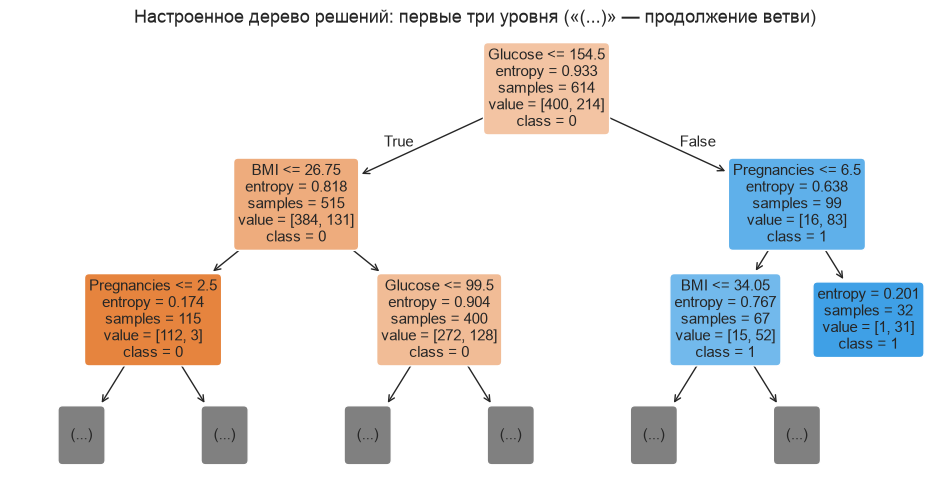

|--- Glucose <= 154.50
|   |--- BMI <= 26.75
|   |   |--- Pregnancies <= 2.50
|   |   |   |--- weights: [66.00, 0.00] class: 0
|   |   |--- Pregnancies >  2.50
|   |   |   |--- weights: [46.00, 3.00] class: 0
|   |--- BMI >  26.75
|   |   |--- Glucose <= 99.50
|   |   |   |--- Age <= 25.50
|   |   |   |   |--- weights: [52.00, 2.00] class: 0
|   |   |   |--- Age >  25.50
|   |   |   |   |--- weights: [43.00, 10.00] class: 0
|   |   |--- Glucose >  99.50
|   |   |   |--- Age <= 28.50
|   |   |   |   |--- Glucose <= 127.50
|   |   |   |   |   |--- weights: [75.00, 13.00] class: 0
|   |   |   |   |--- Glucose >  127.50
|   |   |   |   |   |--- weights: [22.00, 18.00] class: 0
|   |   |   |--- Age >  28.50
|   |   |   |   |--- DiabetesPedigreeFunction <= 0.53
|   |   |   |   |   |--- weights: [59.00, 45.00] class: 0
|   |   |   |   |--- DiabetesPedigreeFunction >  0.53
|   |   |   |   |   |--- weights: [21.00, 40.00] class: 1
|--- Glucose >  154.50
|   |--- Pregnancies <= 6.50
|   |   |---

,Важность признака
Glucose,0.610
BMI,0.209
Age,0.108
Pregnancies,0.046
DiabetesPedigreeFunction,0.028
BloodPressure,0.000
SkinThickness,0.000
Insulin,0.000


In [19]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_tree(best_tree, max_depth=2, feature_names=list(X.columns), class_names=['0', '1'],
          filled=True, rounded=True, fontsize=11, ax=ax)
ax.set_title('Настроенное дерево решений: первые три уровня («(...)» — продолжение ветви)')
fig.savefig('Рисунки/tree_plot.png', dpi=200, bbox_inches='tight')
plt.show()

print(export_text(best_tree, feature_names=list(X.columns), show_weights=True))

importances = pd.Series(best_tree.feature_importances_, index=X.columns).sort_values(ascending=False)
display(importances.round(3).to_frame('Важность признака'))
importances.to_csv('Результаты/tree_importances.csv')

На рисунке — первые три уровня настроенного дерева, ниже — всё дерево текстом (`export_text`; в листьях — число объектов классов 0 и 1). Корневое разбиение — Glucose ≤ 154,5: из 614 объектов налево уходят 515 (384 класса 0 и 131 класса 1), направо — 99 (16 и 83), то есть при высокой глюкозе 84 % пациенток относятся к классу 1. В левой ветви дальше используются BMI ≤ 26,75 (при низком ИМТ 112 из 115 объектов — класс 0), Glucose ≤ 99,5, Age и DiabetesPedigreeFunction, в правой — Pregnancies ≤ 6,5 и BMI ≤ 34,05. Важность признаков (нормированное суммарное уменьшение энтропии по разбиениям на этом признаке): Glucose — 0,610, BMI — 0,209, Age — 0,108, Pregnancies — 0,046, DiabetesPedigreeFunction — 0,028; BloodPressure, SkinThickness и Insulin в дереве не участвуют. Glucose — первая и по важности в дереве, и по корреляции с классом.

### 4.3. Линейный дискриминантный анализ: solver и shrinkage

In [20]:
shrink_range = np.round(np.linspace(0, 1, 21), 2)
shrinkages = ['auto'] + list(shrink_range)
lda_grid = GridSearchCV(make_pipe(LinearDiscriminantAnalysis()),
                        param_grid=[{'clf__solver': ['svd']},
                                    {'clf__solver': ['lsqr', 'eigen'], 'clf__shrinkage': shrinkages}],
                        scoring='roc_auc', cv=cv)
lda_grid.fit(X_train, y_train)
print('Лучшие параметры:', params_to_text(lda_grid.best_params_))
print('ROC-AUC (CV):', round(lda_grid.best_score_, 4))

lda_results = pd.DataFrame({'solver': lda_grid.cv_results_['param_clf__solver'],
                            'shrinkage': [str(p.get('clf__shrinkage', '–')) for p in lda_grid.cv_results_['params']],
                            'ROC-AUC (CV)': lda_grid.cv_results_['mean_test_score']})
display(lda_results.sort_values('ROC-AUC (CV)', ascending=False).head(10).round(4))
lda_results.to_csv('Результаты/lda_grid.csv', index=False)

Лучшие параметры: shrinkage=0.15, solver=lsqr
ROC-AUC (CV): 0.845


,solver,shrinkage,ROC-AUC (CV)
10,eigen,0.15,0.8450
9,lsqr,0.15,0.8450
15,lsqr,0.3,0.8445
16,eigen,0.3,0.8445
11,lsqr,0.2,0.8443
12,eigen,0.2,0.8443
7,lsqr,0.1,0.8443
8,eigen,0.1,0.8443
13,lsqr,0.25,0.8442
14,eigen,0.25,0.8442


Сетка: `solver='svd'` (без сжатия) и `solver` ∈ {lsqr, eigen} с `shrinkage` ∈ {'auto'; 0; 0,05; …; 1} — 45 комбинаций. При одинаковом shrinkage lsqr и eigen дают одинаковый ROC-AUC: они решают одну и ту же задачу разными численными методами, так что solver на качество не влияет. Без сжатия (svd или shrinkage = 0) ROC-AUC = 0,8431, лучший результат — shrinkage = 0,15 (0,8450); 'auto' (формула Ледуа — Вольфа) даёт 0,8441.

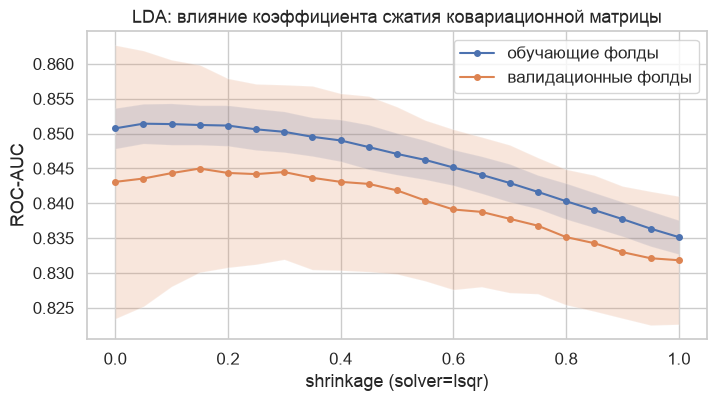

shrinkage,0.00,0.10,0.15,0.20,0.30,0.50,0.70,1.00
train,0.8507,0.8514,0.8512,0.8511,0.8502,0.8471,0.8429,0.8351
valid,0.8431,0.8443,0.8450,0.8443,0.8445,0.8418,0.8378,0.8318


In [21]:
lda_train, lda_valid = validation_curve(make_pipe(LinearDiscriminantAnalysis(solver='lsqr')), X_train, y_train,
                                        param_name='clf__shrinkage', param_range=shrink_range,
                                        cv=cv, scoring='roc_auc')
fig, ax = plt.subplots(figsize=(8, 4))
plot_validation(ax, shrink_range, lda_train, lda_valid, 'shrinkage (solver=lsqr)')
ax.set_title('LDA: влияние коэффициента сжатия ковариационной матрицы')
fig.savefig('Рисунки/lda_shrinkage.png', dpi=200, bbox_inches='tight')
plt.show()
lda_curve = pd.DataFrame({'shrinkage': shrink_range, 'train': lda_train.mean(axis=1),
                          'valid': lda_valid.mean(axis=1)})
lda_curve.to_csv('Результаты/curve_lda.csv', index=False)
display(lda_curve[lda_curve['shrinkage'].isin([0, 0.1, 0.15, 0.2, 0.3, 0.5, 0.7, 1])].set_index('shrinkage').T.round(4))

ROC-AUC на валидационных фолдах слабо растёт от 0,8431 (shrinkage = 0) до 0,8450 (0,15) и при сильном сжатии падает до 0,8318 (shrinkage = 1). При shrinkage = 1 ковариационная матрица заменяется диагональной с одинаковыми дисперсиями, и LDA перестаёт учитывать корреляции признаков. Выигрыш от настройки — 0,0019, меньше стандартного отклонения по фолдам (0,0149), так что LDA с параметрами по умолчанию практически не уступает настроенной. Кривые train и valid близки (0,851 и 0,843 без сжатия): линейная модель на 8 признаках не переобучается.

### 4.4. Метод опорных векторов: kernel, C, gamma

Лучшие параметры: C=100, gamma=0.001, kernel=rbf
ROC-AUC (CV): 0.8464


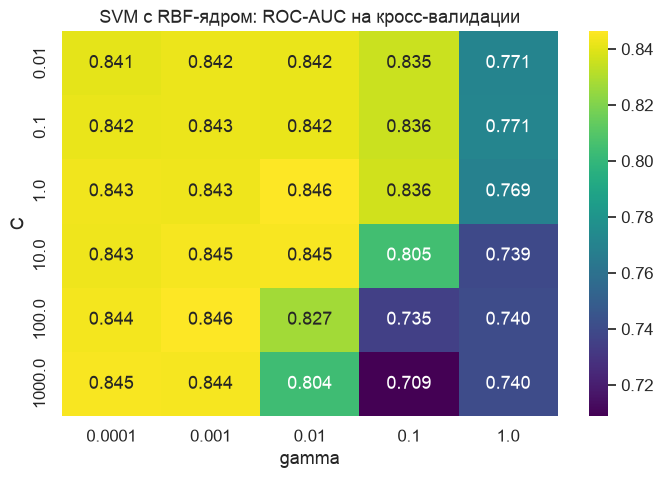

ROC-AUC на обучающих фолдах (RBF):


param_clf__gamma,0.0001,0.0010,0.0100,0.1000,1.0000
param_clf__C,,,,,
0.01,0.846,0.847,0.848,0.856,0.994
0.10,0.847,0.848,0.848,0.858,0.993
1.00,0.848,0.848,0.854,0.897,0.996
10.00,0.848,0.852,0.869,0.950,1.000
100.00,0.851,0.856,0.894,0.988,1.000
1000.00,0.851,0.868,0.920,0.999,1.000


,C,ROC-AUC (CV)
30,0.001,0.8428
31,0.010,0.8459
32,0.100,0.8441
33,1.000,0.8446
34,10.000,0.8447
35,100.000,0.8447


In [22]:
C_values = [0.01, 0.1, 1, 10, 100, 1000]
gamma_values = [0.0001, 0.001, 0.01, 0.1, 1]
svm_grid = GridSearchCV(make_pipe(SVC()),
                        param_grid=[{'clf__kernel': ['rbf'], 'clf__C': C_values, 'clf__gamma': gamma_values},
                                    {'clf__kernel': ['linear'], 'clf__C': [0.001, 0.01, 0.1, 1, 10, 100]}],
                        scoring='roc_auc', cv=cv, return_train_score=True)
svm_grid.fit(X_train, y_train)
print('Лучшие параметры:', params_to_text(svm_grid.best_params_))
print('ROC-AUC (CV):', round(svm_grid.best_score_, 4))

svm_results = pd.DataFrame(svm_grid.cv_results_)
rbf = svm_results[svm_results['param_clf__kernel'] == 'rbf']
svm_heat = rbf.pivot_table(index='param_clf__C', columns='param_clf__gamma', values='mean_test_score')
svm_heat.to_csv('Результаты/svm_heatmap.csv')
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(svm_heat, annot=True, fmt='.3f', cmap='viridis', ax=ax)
ax.set_xlabel('gamma')
ax.set_ylabel('C')
ax.set_title('SVM с RBF-ядром: ROC-AUC на кросс-валидации')
fig.savefig('Рисунки/svm_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

svm_heat_train = rbf.pivot_table(index='param_clf__C', columns='param_clf__gamma', values='mean_train_score')
svm_heat_train.to_csv('Результаты/svm_heatmap_train.csv')
print('ROC-AUC на обучающих фолдах (RBF):')
display(svm_heat_train.round(3))

linear = svm_results[svm_results['param_clf__kernel'] == 'linear']
svm_linear = pd.DataFrame({'C': linear['param_clf__C'].astype(float),
                           'ROC-AUC (CV)': linear['mean_test_score']})
svm_linear.to_csv('Результаты/svm_linear.csv', index=False)
display(svm_linear.round(4))

Сетка: RBF-ядро с C ∈ {0,01; 0,1; 1; 10; 100; 1000} и gamma ∈ {0,0001; 0,001; 0,01; 0,1; 1} плюс линейное ядро с C ∈ {0,001; 0,01; 0,1; 1; 10; 100} — 36 комбинаций. Лучшие параметры — RBF, C = 100, gamma = 0,001: ROC-AUC 0,8464 (по умолчанию 0,8333). По тепловой карте видно, как действуют параметры: при gamma 0,0001–0,001 ROC-AUC держится на уровне 0,841–0,846 при любом C; с ростом gamma и C граница становится слишком «извилистой» и качество падает — 0,804 при gamma = 0,01 и C = 1000, 0,709 при gamma = 0,1 и C = 1000, 0,739–0,771 при gamma = 1. На обучающих фолдах при тех же параметрах ROC-AUC 0,993–1,000 (при gamma = 1) и 0,999 (gamma = 0,1, C = 1000): модель запоминает обучающие объекты — это переобучение. Лучший линейный SVM (C = 0,01) даёт 0,8459 — почти столько же, сколько лучший RBF: RBF-ядро с малым gamma и большим C ведёт себя почти как линейная граница, и нелинейность на этих данных заметного выигрыша не даёт.

### 4.5. Метод k ближайших соседей: n_neighbors, weights, p

Лучшие параметры: n_neighbors=84, p=2, weights=distance
ROC-AUC (CV): 0.8375


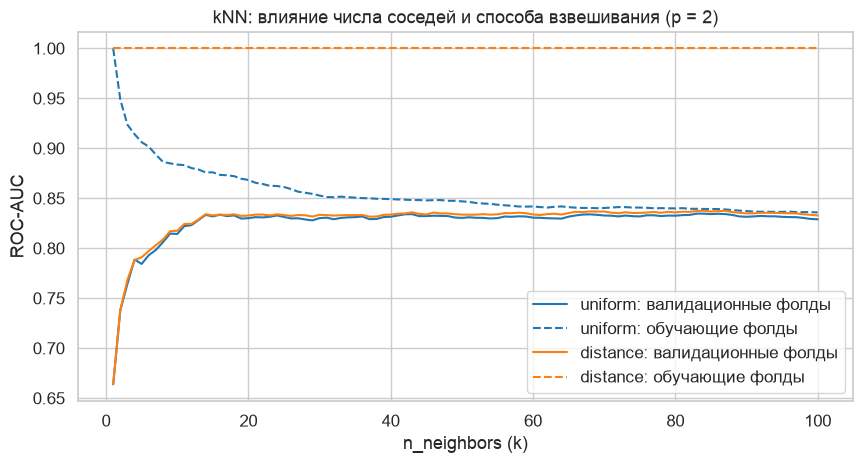

,k,uniform_train,uniform_valid,distance_train,distance_valid
0,1,1.000,0.664,1.0,0.664
2,3,0.924,0.764,1.0,0.768
4,5,0.906,0.784,1.0,0.791
9,10,0.884,0.814,1.0,0.817
14,15,0.876,0.832,1.0,0.833
19,20,0.868,0.830,1.0,0.833
29,30,0.853,0.830,1.0,0.833
39,40,0.849,0.831,1.0,0.834
49,50,0.847,0.830,1.0,0.834
69,70,0.840,0.833,1.0,0.837


In [23]:
k_range = list(range(1, 101))
knn_grid = GridSearchCV(make_pipe(KNeighborsClassifier()),
                        param_grid={'clf__n_neighbors': k_range,
                                    'clf__weights': ['uniform', 'distance'],
                                    'clf__p': [1, 2]},
                        scoring='roc_auc', cv=cv)
knn_grid.fit(X_train, y_train)
print('Лучшие параметры:', params_to_text(knn_grid.best_params_))
print('ROC-AUC (CV):', round(knn_grid.best_score_, 4))

knn_curves = {'k': k_range}
fig, ax = plt.subplots(figsize=(10, 4.8))
for weights, color in [('uniform', 'tab:blue'), ('distance', 'tab:orange')]:
    base = make_pipe(KNeighborsClassifier(weights=weights, p=knn_grid.best_params_['clf__p']))
    train_sc, valid_sc = validation_curve(base, X_train, y_train, param_name='clf__n_neighbors',
                                          param_range=k_range, cv=cv, scoring='roc_auc')
    ax.plot(k_range, valid_sc.mean(axis=1), color=color, label=weights + ': валидационные фолды')
    ax.plot(k_range, train_sc.mean(axis=1), color=color, linestyle='--', label=weights + ': обучающие фолды')
    knn_curves[weights + '_train'] = train_sc.mean(axis=1)
    knn_curves[weights + '_valid'] = valid_sc.mean(axis=1)
ax.set_xlabel('n_neighbors (k)')
ax.set_ylabel('ROC-AUC')
ax.set_title('kNN: влияние числа соседей и способа взвешивания (p = '
             + str(knn_grid.best_params_['clf__p']) + ')')
ax.legend()
fig.savefig('Рисунки/knn_curves.png', dpi=200, bbox_inches='tight')
plt.show()
knn_curves = pd.DataFrame(knn_curves)
knn_curves.to_csv('Результаты/curve_knn.csv', index=False)
display(knn_curves[knn_curves['k'].isin([1, 3, 5, 10, 15, 20, 30, 40, 50, 70, 100])].round(3))

Сетка: k от 1 до 100, weights ∈ {uniform, distance}, p ∈ {1, 2} — 400 комбинаций. Лучшие параметры: k = 84, евклидово расстояние (p = 2), взвешивание по расстоянию; ROC-AUC 0,8375 против 0,784 по умолчанию (k = 5). При k = 1 ROC-AUC на валидационных фолдах всего 0,664, а на обучающих — 1,0: каждый обучающий объект — сам себе ближайший сосед (переобучение). С ростом k оценка вероятности усредняется по большему числу соседей, ROC-AUC растёт и примерно с k = 15 выходит на плато: при weights = distance все значения для k от 15 до 100 лежат в диапазоне 0,832–0,837, поэтому выбор k = 84 внутри плато почти не важен. Взвешивание по расстоянию добавляет на валидационных фолдах до 0,007 (при k = 5: 0,791 против 0,784); на обучающих фолдах при weights = distance ROC-AUC всегда 1,0 — объект находится на нулевом расстоянии от самого себя и получает весь вес.

### 4.6. Итог настройки: «по умолчанию → после настройки»

In [24]:
grids = {'Наивный Байес': nb_grid, 'Дерево решений': tree_grid, 'LDA': lda_grid,
         'SVM': svm_grid, 'kNN': knn_grid}
best_models = {name: grid.best_estimator_ for name, grid in grids.items()}

tuning = pd.DataFrame({
    'Лучшие параметры': {name: params_to_text(g.best_params_) for name, g in grids.items()},
    'ROC-AUC по умолчанию': default_cv['roc_auc'],
    'ROC-AUC после настройки': {name: g.best_score_ for name, g in grids.items()},
    'Ст. откл. после настройки': {name: g.cv_results_['std_test_score'][g.best_index_]
                                  for name, g in grids.items()},
})
tuning['Прирост'] = tuning['ROC-AUC после настройки'] - tuning['ROC-AUC по умолчанию']
display(tuning.round(4))
tuning.to_csv('Результаты/tuning.csv')

,Лучшие параметры,ROC-AUC по умолчанию,ROC-AUC после настройки,Ст. откл. после настройки,Прирост
Наивный Байес,var_smoothing=1e-06,0.8281,0.8288,0.0088,0.0007
Дерево решений,"criterion=entropy, max_depth=5, min_samples_le...",0.6510,0.8055,0.0315,0.1545
LDA,"shrinkage=0.15, solver=lsqr",0.8431,0.8450,0.0149,0.0019
SVM,"C=100, gamma=0.001, kernel=rbf",0.8333,0.8464,0.0157,0.0131
kNN,"n_neighbors=84, p=2, weights=distance",0.7843,0.8375,0.0181,0.0531


Итог по кросс-валидации (средний ROC-AUC по 5 фолдам): настройка сильнее всего помогла дереву решений (с 0,651 до 0,805, +0,154) и kNN (с 0,784 до 0,837, +0,053) — у этих методов параметры по умолчанию дают переобученные модели (неограниченное дерево, k = 5). SVM прибавил 0,013 (до 0,846), а LDA (+0,002, до 0,845) и наивный Байес (+0,001, до 0,829) почти не изменились: их качество слабо зависит от гиперпараметров. Лучшие по кросс-валидации — SVM и LDA; разница между ними (0,001) намного меньше стандартного отклонения по фолдам (0,015–0,016).

## 5. Метрики на тестовой выборке

Модели с лучшими параметрами (обученные на всей обучающей выборке) оцениваются на тестовой выборке, которая не использовалась ни при обучении, ни при настройке. Класс 1 (диабет выявлен) считается положительным. Обозначения матрицы ошибок: TP — больные, отнесённые к больным; TN — здоровые, отнесённые к здоровым; FP — здоровые, ошибочно отнесённые к больным; FN — пропущенные больные.

- Accuracy (в задании — «точность»): $\dfrac{TP + TN}{TP + TN + FP + FN}$ — доля верных ответов;
- Precision: $\dfrac{TP}{TP + FP}$ — доля действительно больных среди отнесённых к классу 1;
- Recall (чувствительность): $\dfrac{TP}{TP + FN}$ — доля найденных больных среди всех больных;
- F1: $2\cdot\dfrac{\text{Precision}\cdot\text{Recall}}{\text{Precision} + \text{Recall}}$ — среднее гармоническое precision и recall;
- ROC-AUC — площадь под ROC-кривой, то есть под зависимостью $TPR = \dfrac{TP}{TP + FN}$ от $FPR = \dfrac{FP}{FP + TN}$ при изменении порога; равна вероятности того, что случайно выбранный больной получит оценку выше случайно выбранного здорового (0,5 — случайное угадывание, 1 — идеальное разделение).

Первые четыре метрики считаются по меткам классов (порог 0,5 для вероятности; у SVM — знак решающей функции), ROC-AUC — по непрерывным оценкам: вероятности класса 1, а у `SVC` — значению решающей функции. Параметр `probability=True` у `SVC` в scikit-learn 1.9 объявлен устаревшим, а для ROC-AUC важен только порядок оценок, поэтому решающей функции достаточно.

In [25]:
def positive_scores(model, X_part):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_part)[:, 1]
    return model.decision_function(X_part)

def test_metrics(y_true, y_pred, y_score):
    return {'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred),
            'f1': f1_score(y_true, y_pred, zero_division=0),
            'roc_auc': roc_auc_score(y_true, y_score)}

test_results = {name: test_metrics(y_test, model.predict(X_test), positive_scores(model, X_test))
                for name, model in best_models.items()}
test_table = pd.DataFrame(test_results).T
display(test_table.round(3))
test_table.to_csv('Результаты/test_metrics.csv')

,accuracy,precision,recall,f1,roc_auc
Наивный Байес,0.701,0.567,0.630,0.596,0.764
Дерево решений,0.779,0.778,0.519,0.622,0.838
LDA,0.701,0.587,0.500,0.540,0.808
SVM,0.695,0.578,0.481,0.525,0.817
kNN,0.721,0.649,0.444,0.527,0.800


На тестовой выборке (154 объекта) лучшие accuracy (0,779), precision (0,778), F1 (0,622) и ROC-AUC (0,838) у дерева решений, наибольший recall — у наивного Байеса (0,630). У SVM ROC-AUC 0,817, у LDA — 0,808, у kNN — 0,800, у наивного Байеса — 0,764. Recall всех методов при пороге 0,5 не выше 0,630: они пропускают от 20 до 30 из 54 больных (матрицы ошибок ниже). Порядок методов на тесте отличается от кросс-валидации, где дерево последнее; насколько надёжны эти различия, проверено в разделе 8.

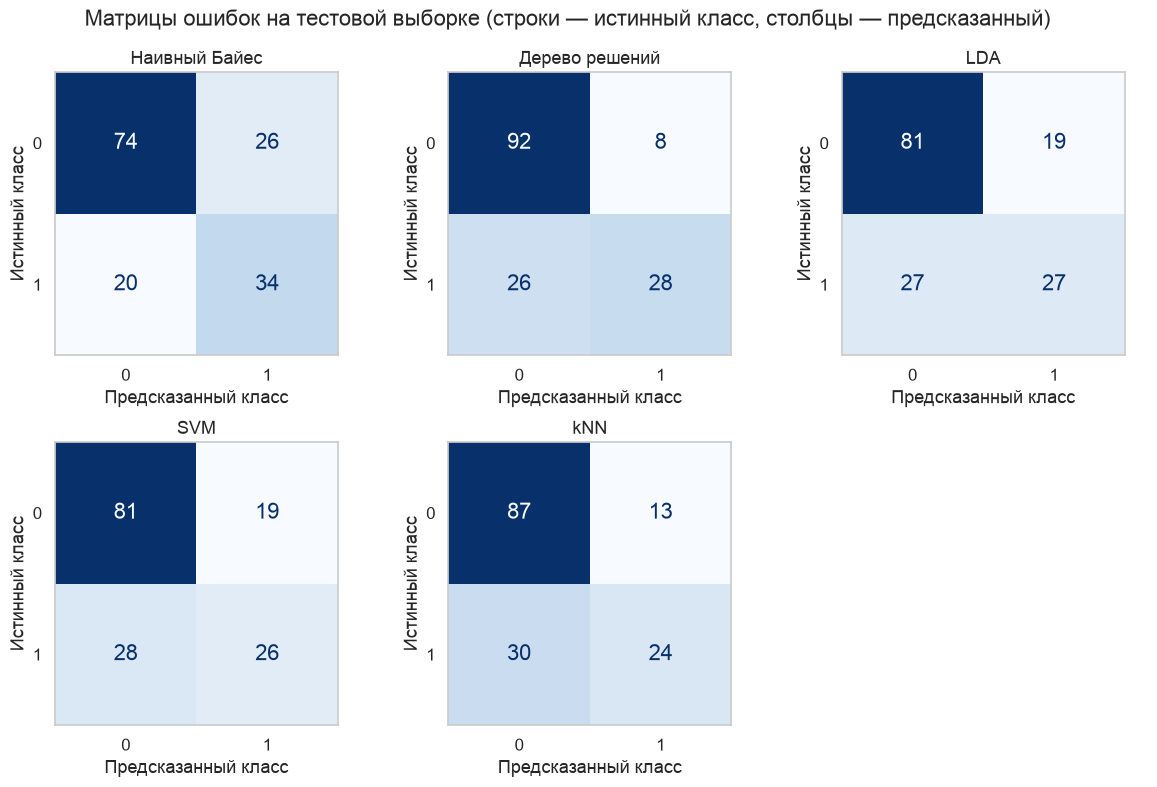

,TN,FP,FN,TP
Наивный Байес,74,26,20,34
Дерево решений,92,8,26,28
LDA,81,19,27,27
SVM,81,19,28,26
kNN,87,13,30,24


In [26]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
confusion = {}
for ax, (name, model) in zip(axes.ravel(), best_models.items()):
    y_pred = model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False, cmap='Blues',
                                            text_kw={'fontsize': 16})
    ax.grid(False)
    ax.set_title(name)
    ax.set_xlabel('Предсказанный класс')
    ax.set_ylabel('Истинный класс')
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    confusion[name] = {'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)}
axes[1, 2].axis('off')
fig.suptitle('Матрицы ошибок на тестовой выборке (строки — истинный класс, столбцы — предсказанный)')
fig.tight_layout()
fig.savefig('Рисунки/confusion_matrices.png', dpi=200, bbox_inches='tight')
plt.show()
confusion = pd.DataFrame(confusion).T
display(confusion)
confusion.to_csv('Результаты/confusion.csv')

Строки матрицы — истинный класс, столбцы — предсказанный. Пропущенных больных (FN) меньше всего у наивного Байеса (20 из 54), больше всего у kNN (30) и SVM (28); у дерева — 26, у LDA — 27. Ложных тревог (FP) меньше всего у дерева (8 из 100 здоровых) и kNN (13), больше всего у наивного Байеса (26). Наивный Байес чаще относит объекты к классу 1 (precision 0,567, recall 0,630), дерево и kNN — реже (precision 0,778 и 0,649, recall 0,519 и 0,444). При одном и том же пороге 0,5 методы выбирают разный компромисс между двумя видами ошибок.

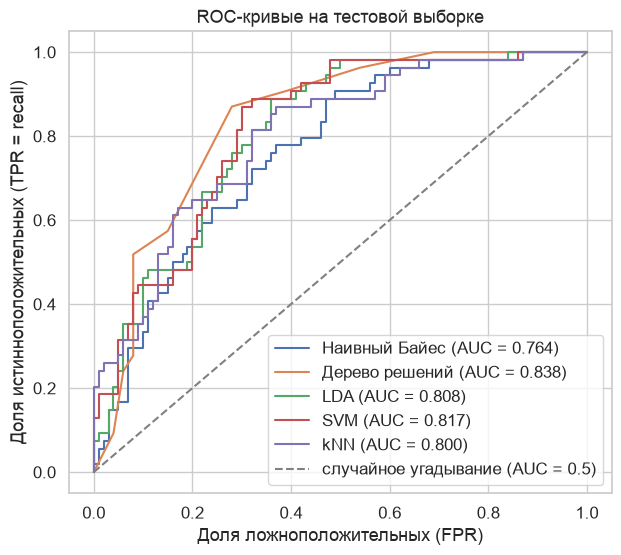

In [27]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in best_models.items():
    fpr, tpr, _ = roc_curve(y_test, positive_scores(model, X_test))
    ax.plot(fpr, tpr, label=name + ' (AUC = ' + format(test_table.loc[name, 'roc_auc'], '.3f') + ')')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', label='случайное угадывание (AUC = 0.5)')
ax.set_xlabel('Доля ложноположительных (FPR)')
ax.set_ylabel('Доля истинноположительных (TPR = recall)')
ax.set_title('ROC-кривые на тестовой выборке')
ax.legend(loc='lower right')
fig.savefig('Рисунки/roc_curves.png', dpi=200, bbox_inches='tight')
plt.show()

ROC-кривая показывает, как меняются TPR (recall) и FPR при всех порогах. Площади под кривыми: дерево — 0,838, SVM — 0,817, LDA — 0,808, kNN — 0,800, наивный Байес — 0,764; все кривые лежат выше диагонали случайного угадывания. Кривая дерева состоит из нескольких прямых отрезков: у дерева 11 листьев, значит, не больше 11 разных значений вероятности. Кривые пересекаются: при очень малой доле ложных тревог (FPR до 0,05) выше других kNN и SVM, при FPR от 0,08 до 0,3 — дерево, а при FPR больше 0,4 дерево, LDA и SVM почти совпадают. Единого лучшего классификатора для всех порогов нет.

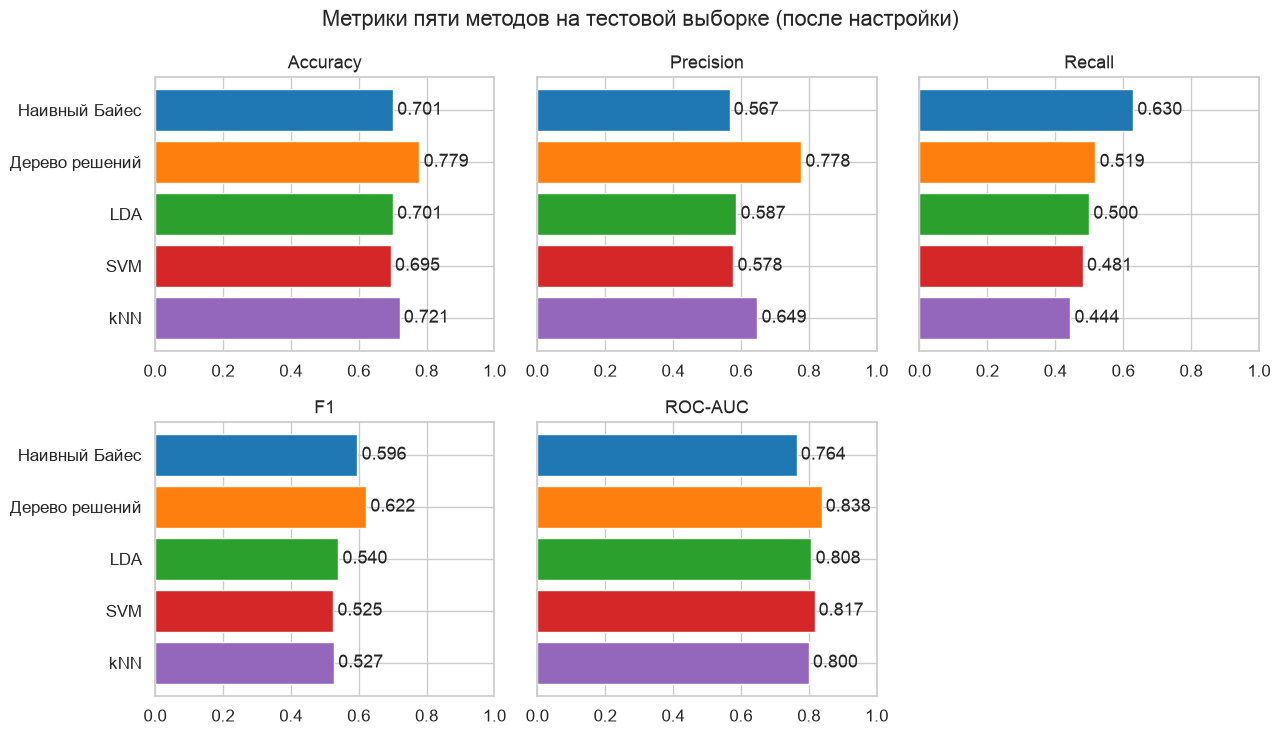

In [28]:
metric_names = {'accuracy': 'Accuracy', 'precision': 'Precision', 'recall': 'Recall',
                'f1': 'F1', 'roc_auc': 'ROC-AUC'}
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5), sharey=True)
for ax, (metric, title) in zip(axes.ravel(), metric_names.items()):
    values = test_table[metric][::-1]
    bars = ax.barh(values.index, values.values, color=sns.color_palette('tab10', 5)[::-1])
    ax.bar_label(bars, fmt='%.3f', padding=3)
    ax.set_title(title)
    ax.set_xlim(0, 1)
axes[1, 2].axis('off')
fig.suptitle('Метрики пяти методов на тестовой выборке (после настройки)')
fig.tight_layout()
fig.savefig('Рисунки/metrics_bars.png', dpi=200, bbox_inches='tight')
plt.show()

Столбчатые диаграммы по каждой метрике (рекомендация 5) показывают те же числа: по accuracy, precision, F1 и ROC-AUC впереди дерево решений, по recall — наивный Байес (0,630) при самой низкой precision (0,567). У kNN самый низкий recall (0,444), у SVM — самые низкие accuracy (0,695) и F1 (0,525). Метрики ранжируют методы по-разному, поэтому вывод о лучшем методе делается по их совокупности и с учётом кросс-валидации (раздел 8).

In [29]:
default_test = {}
for name, model in models_default.items():
    model.fit(X_train, y_train)
    default_test[name] = test_metrics(y_test, model.predict(X_test), positive_scores(model, X_test))
default_test = pd.DataFrame(default_test).T
effect = pd.DataFrame({'ROC-AUC по умолчанию': default_test['roc_auc'],
                       'ROC-AUC после настройки': test_table['roc_auc'],
                       'F1 по умолчанию': default_test['f1'],
                       'F1 после настройки': test_table['f1']})
display(effect.round(3))
default_test.to_csv('Результаты/default_test.csv')

,ROC-AUC по умолчанию,ROC-AUC после настройки,F1 по умолчанию,F1 после настройки
Наивный Байес,0.765,0.764,0.596,0.596
Дерево решений,0.636,0.838,0.515,0.622
LDA,0.813,0.808,0.531,0.540
SVM,0.796,0.817,0.600,0.525
kNN,0.790,0.800,0.635,0.527


На тестовой выборке эффект настройки неоднозначен. ROC-AUC вырос у дерева (с 0,636 до 0,838), SVM (с 0,796 до 0,817) и kNN (с 0,790 до 0,800), у наивного Байеса не изменился (0,765 и 0,764), у LDA немного снизился (с 0,813 до 0,808). F1 при пороге 0,5 вырос у дерева (с 0,515 до 0,622) и LDA (с 0,531 до 0,540), но снизился у SVM (с 0,600 до 0,525) и kNN (с 0,635 до 0,527). Настройка шла по ROC-AUC, который от порога не зависит, а настроенные SVM и kNN при пороге 0,5 реже относят объекты к классу 1 (recall 0,481 и 0,444 против 0,556 и 0,611 по умолчанию). Порог можно выбрать отдельно — это показано в разделе 8.

## 6. Нейронная сеть на TensorFlow

Сеть — полносвязная (многослойный перцептрон), собирается в Keras: `Input(8)` → скрытые слои `Dense` с функцией активации → выходной слой `Dense(1, activation='sigmoid')`. Нейрон слоя `Dense` вычисляет $a = f(w^T x + b)$, где $w$ — веса, $b$ — смещение, $f$ — функция активации; ReLU: $f(z) = \max(0, z)$. Сигмоида на выходе $\sigma(z) = 1/(1 + e^{-z})$ даёт вероятность класса 1. Функция потерь — бинарная кросс-энтропия $L = -\dfrac1n\sum_{i=1}^n\left[y_i\ln p_i + (1 - y_i)\ln(1 - p_i)\right]$; оптимизатор — Adam (градиентный спуск, в котором шаг для каждого веса подстраивается по скользящим средним градиента и его квадрата). Метрики при обучении — accuracy и AUC.

Для наблюдения за обучением из обучающей выборки выделена валидационная часть (20 %, со стратификацией): сеть обучается на одной части, а после каждой эпохи loss и метрики считаются и на валидационной части. Предобработка (медиана + стандартизация) обучается только на обучающей части. Тестовая выборка в экспериментах не используется — только для итоговой проверки.

Исходная (базовая) конфигурация: два скрытых слоя по 16 и 8 нейронов, ReLU, Adam с learning_rate = 0,001, 100 эпох, батч 32. В каждом эксперименте меняется один гиперпараметр (рекомендация 7): число эпох, размер батча, число слоёв и нейронов, функция активации; отдельно проверена ранняя остановка. Для каждого запуска коллбэк `TensorBoard` пишет логи в `logs/fit/<имя запуска>` (рекомендация 6); просмотр: `tensorboard --logdir logs`.

In [30]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train,
                                            random_state=RANDOM_STATE)

def make_prep():
    return Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])

nn_prep = make_prep()
X_tr_s = nn_prep.fit_transform(X_tr)
X_val_s = nn_prep.transform(X_val)
X_test_s = nn_prep.transform(X_test)
print('Обучение:', X_tr_s.shape, ' валидация:', X_val_s.shape, ' тест:', X_test_s.shape)
print('Доля класса 1: обучение', round(y_tr.mean(), 3), ' валидация', round(y_val.mean(), 3))
summary['nn_train_size'], summary['nn_val_size'] = int(len(y_tr)), int(len(y_val))

Обучение: (491, 8)  валидация: (123, 8)  тест: (154, 8)
Доля класса 1: обучение 0.348  валидация 0.35


Обучающая выборка разделена ещё раз (80/20 со стратификацией и тем же seed): 491 объект для обучения сети и 123 — валидационная часть для контроля после каждой эпохи; доля класса 1 — 0,348 и 0,350. Функция `make_prep` создаёт конвейер «медиана → стандартизация»; он обучается (`fit_transform`) только на 491 объекте, а валидационная и тестовая части лишь преобразуются (`transform`) с теми же медианами, средними и стандартными отклонениями.

In [31]:
def make_network(hidden_layers=(16, 8), activation='relu', learning_rate=0.001):
    tf.keras.utils.set_random_seed(RANDOM_STATE)
    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=(X_tr_s.shape[1],)))
    for units in hidden_layers:
        model.add(tf.keras.layers.Dense(units, activation=activation))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

make_network().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

Базовая сеть: Dense(16, ReLU) → Dense(8, ReLU) → Dense(1, sigmoid). Число параметров слоя = (входы × нейроны) + нейроны (смещения): 8·16 + 16 = 144, 16·8 + 8 = 136, 8·1 + 1 = 9, всего 289 обучаемых параметров. В размерности выхода `(None, 16)` первое измерение `None` — произвольный размер батча.

In [32]:
nn_histories, nn_models, nn_rows = {}, {}, []

def run_experiment(name, hidden_layers=(16, 8), activation='relu', epochs=100, batch_size=32,
                   early_stopping=False):
    model = make_network(hidden_layers, activation)
    callbacks = [tf.keras.callbacks.TensorBoard(log_dir='logs/fit/' + name)]
    if early_stopping:
        callbacks.append(tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20,
                                                          restore_best_weights=True))
    history = model.fit(X_tr_s, y_tr, validation_data=(X_val_s, y_val), epochs=epochs,
                        batch_size=batch_size, verbose=0, callbacks=callbacks)
    train_loss, train_acc, train_auc = model.evaluate(X_tr_s, y_tr, verbose=0)
    val_loss, val_acc, val_auc = model.evaluate(X_val_s, y_val, verbose=0)
    nn_histories[name] = history.history
    nn_models[name] = model
    nn_rows.append({'Запуск': name, 'Скрытые слои': '-'.join(map(str, hidden_layers)),
                    'Активация': activation, 'Параметров': model.count_params(),
                    'Эпох': len(history.history['loss']), 'Батч': batch_size,
                    'loss': train_loss, 'accuracy': train_acc, 'auc': train_auc, 'val_loss': val_loss,
                    'val_accuracy': val_acc, 'val_auc': val_auc,
                    'Мин. val_loss': min(history.history['val_loss']),
                    'Эпоха мин. val_loss': int(np.argmin(history.history['val_loss'])) + 1})
    return history.history

def plot_history(ax_loss, ax_acc, history, label, color):
    epochs = range(1, len(history['loss']) + 1)
    ax_loss.plot(epochs, history['loss'], color=color, linestyle='--', linewidth=1)
    ax_loss.plot(epochs, history['val_loss'], color=color, label=label)
    ax_acc.plot(epochs, history['accuracy'], color=color, linestyle='--', linewidth=1)
    ax_acc.plot(epochs, history['val_accuracy'], color=color, label=label)

def plot_runs(names, title, filename):
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(13, 4.6))
    for name, color in zip(names, sns.color_palette('tab10', len(names))):
        plot_history(ax_loss, ax_acc, nn_histories[name], name, color)
    ax_loss.set_title('loss (пунктир) и val_loss (линия)')
    ax_acc.set_title('accuracy (пунктир) и val_accuracy (линия)')
    for ax in (ax_loss, ax_acc):
        ax.set_xlabel('Эпоха')
        ax.legend()
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig('Рисунки/' + filename, dpi=200, bbox_inches='tight')
    plt.show()

`run_experiment` создаёт сеть, обучает её (`fit` с `validation_data` — после каждой эпохи loss и метрики считаются и на валидационной части; `verbose=0` отключает построчный вывод прогресса), пишет лог TensorBoard в `logs/fit/<имя>` и сохраняет историю и итоговые метрики: loss и accuracy на обучающей части, val_loss, val_accuracy и val_auc на валидационной, а также минимальный val_loss и эпоху, на которой он достигнут. Итоговые метрики считает `evaluate` для модели после последней эпохи. `plot_runs` рисует кривые нескольких запусков: пунктир — обучающая часть, сплошная линия — валидационная.

### 6.1. Исходная (базовая) сеть

,Запуск,Скрытые слои,Активация,Параметров,Эпох,Батч,loss,accuracy,auc,val_loss,val_accuracy,val_auc,Мин. val_loss,Эпоха мин. val_loss
0,baseline,16-8,relu,289,100,32,0.3813,0.8269,0.8981,0.4196,0.7724,0.8744,0.4168,70


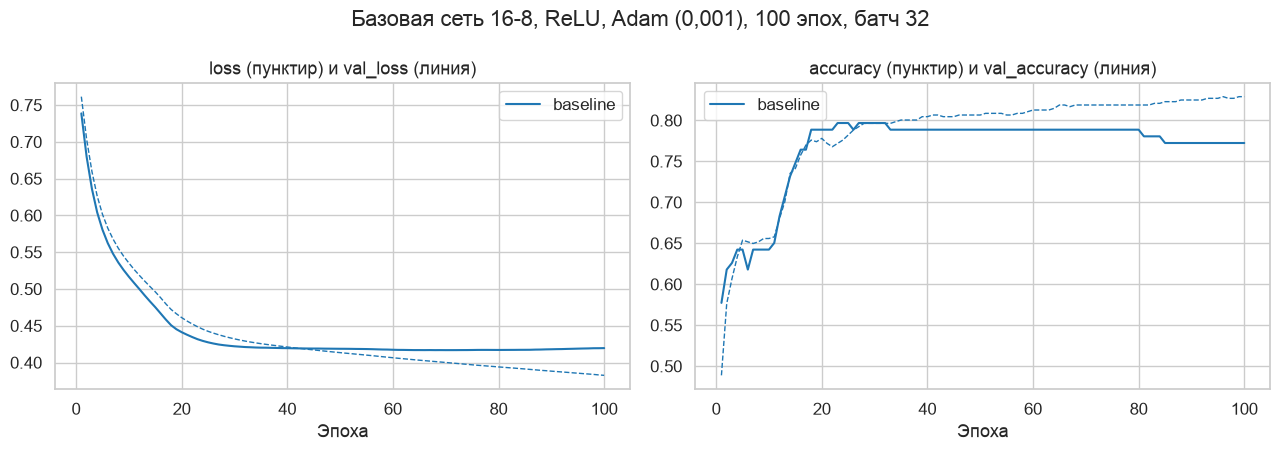

In [33]:
run_experiment('baseline')
display(pd.DataFrame(nn_rows).round(4))
plot_runs(['baseline'], 'Базовая сеть 16-8, ReLU, Adam (0,001), 100 эпох, батч 32', 'nn_baseline.png')

Базовая сеть за 100 эпох: на обучающей части loss 0,381 и accuracy 0,827, на валидационной — val_loss 0,420, val_accuracy 0,772, val_auc 0,874. Минимум val_loss (0,417) достигнут на 70-й эпохе; после этого val_loss почти не меняется, а loss продолжает снижаться — кривые начинают расходиться, это первые признаки переобучения. Кривые accuracy ступенчатые: одна ошибка на 123 валидационных объектах меняет accuracy на 0,008.

### 6.2. Число эпох

Первые 50 эпох запусков на 50 и 400 эпох совпадают: True


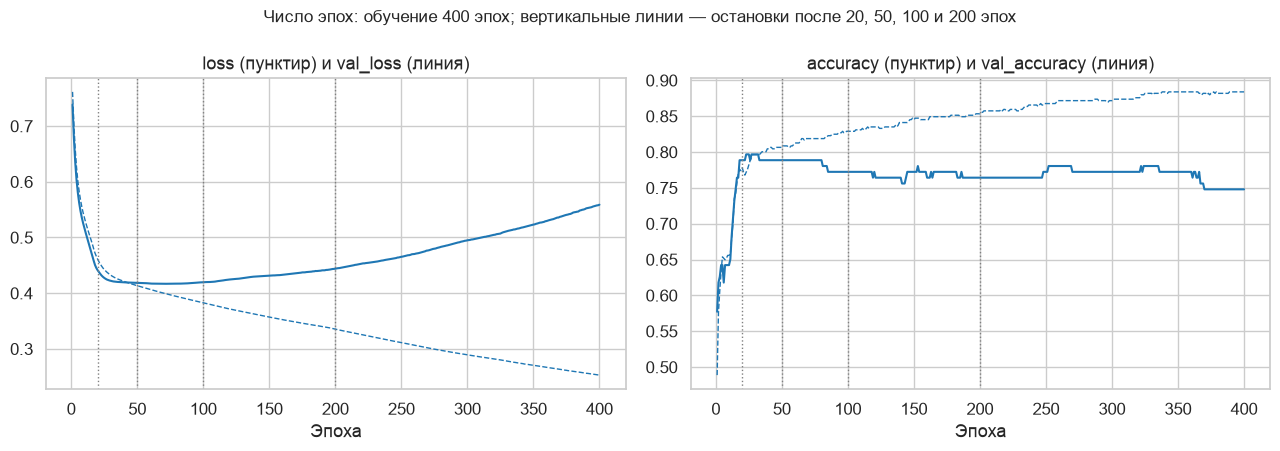

,Запуск,Скрытые слои,Активация,Параметров,Эпох,Батч,loss,accuracy,auc,val_loss,val_accuracy,val_auc,Мин. val_loss,Эпоха мин. val_loss
0,baseline,16-8,relu,289,100,32,0.3813,0.8269,0.8981,0.4196,0.7724,0.8744,0.4168,70
1,epochs_20,16-8,relu,289,20,32,0.4583,0.7760,0.8543,0.4412,0.7886,0.8644,0.4412,20
2,epochs_50,16-8,relu,289,50,32,0.4122,0.8086,0.8801,0.4187,0.7886,0.8706,0.4187,50
3,epochs_200,16-8,relu,289,200,32,0.3337,0.8554,0.9244,0.4441,0.7642,0.8644,0.4168,70
4,epochs_400,16-8,relu,289,400,32,0.2509,0.8839,0.9602,0.5589,0.7480,0.8297,0.4168,70


In [34]:
for epochs in [20, 50, 200, 400]:
    run_experiment('epochs_' + str(epochs), epochs=epochs)

same_start = np.allclose(nn_histories['epochs_50']['val_loss'], nn_histories['epochs_400']['val_loss'][:50])
print('Первые 50 эпох запусков на 50 и 400 эпох совпадают:', same_start)

fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(13, 4.6))
plot_history(ax_loss, ax_acc, nn_histories['epochs_400'], 'обучение 400 эпох', 'tab:blue')
for ax in (ax_loss, ax_acc):
    for stop in [20, 50, 100, 200]:
        ax.axvline(stop, color='grey', linestyle=':', linewidth=1)
    ax.set_xlabel('Эпоха')
ax_loss.set_title('loss (пунктир) и val_loss (линия)')
ax_acc.set_title('accuracy (пунктир) и val_accuracy (линия)')
fig.suptitle('Число эпох: обучение 400 эпох; вертикальные линии — остановки после 20, 50, 100 и 200 эпох',
             fontsize=12)
fig.tight_layout()
fig.savefig('Рисунки/nn_epochs.png', dpi=200, bbox_inches='tight')
plt.show()
display(pd.DataFrame(nn_rows).round(4))

При фиксированном seed обучение на 50 эпох в точности совпадает с первыми 50 эпохами обучения на 400 (проверка выше дала `True`), поэтому пять запусков — это остановки на одной траектории, показанной на рисунке. 20 эпох мало (недообучение): loss 0,458, val_loss 0,441. При 50 и 100 эпохах val_loss близок к минимуму (0,419 и 0,420; минимум 0,417 — на 70-й эпохе). Дальше сеть переобучается: loss падает до 0,334 (200 эпох) и 0,251 (400 эпох), accuracy на обучающей части растёт до 0,884, а val_loss растёт до 0,444 и 0,559, val_accuracy падает до 0,748, val_auc — с 0,874 до 0,830. Разумное число эпох для этой сети — 50–100.

### 6.3. Размер батча

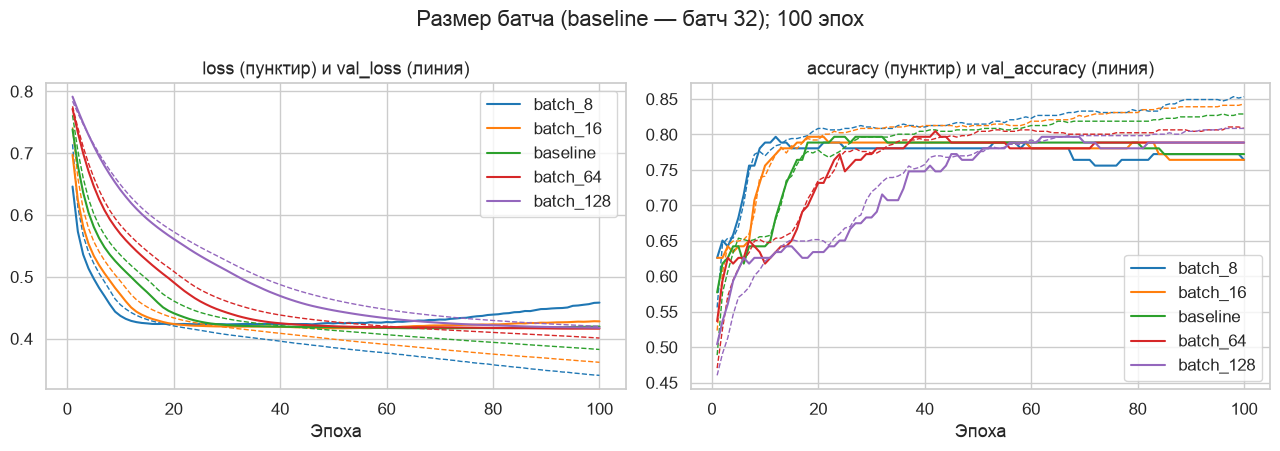

,Запуск,Скрытые слои,Активация,Параметров,Эпох,Батч,loss,accuracy,auc,val_loss,val_accuracy,val_auc,Мин. val_loss,Эпоха мин. val_loss
5,batch_8,16-8,relu,289,100,8,0.3347,0.8534,0.9244,0.4583,0.7642,0.8557,0.4231,30
6,batch_16,16-8,relu,289,100,16,0.3588,0.8452,0.9117,0.4280,0.7642,0.8703,0.4168,51
7,batch_64,16-8,relu,289,100,64,0.4004,0.8106,0.8867,0.4162,0.7886,0.8718,0.4162,95
8,batch_128,16-8,relu,289,100,128,0.4195,0.8086,0.8760,0.4176,0.7886,0.8711,0.4176,100


In [35]:
for batch in [8, 16, 64, 128]:
    run_experiment('batch_' + str(batch), batch_size=batch)
plot_runs(['batch_8', 'batch_16', 'baseline', 'batch_64', 'batch_128'],
          'Размер батча (baseline — батч 32); 100 эпох', 'nn_batch.png')
display(pd.DataFrame(nn_rows).round(4).tail(4))

Размер батча задаёт число шагов градиентного спуска за эпоху: ⌈491/8⌉ = 62 шага при батче 8 и 4 шага при батче 128. С маленьким батчем сеть обучается быстрее и раньше начинает переобучаться: при батче 8 минимум val_loss (0,423) достигнут уже на 30-й эпохе, а к 100-й val_loss вырос до 0,458; при батче 16 минимум — на 51-й эпохе. С большим батчем обучение медленнее: при 64 и 128 минимум val_loss приходится на 95-ю и 100-ю эпохи (0,416 и 0,418), то есть за 100 эпох эти сети ещё не начали переобучаться. Наименьший итоговый val_loss у батча 64 (0,416), но отличие от батча 32 (0,420) мало; размер батча и число эпох нужно подбирать вместе.

### 6.4. Число слоёв и нейронов

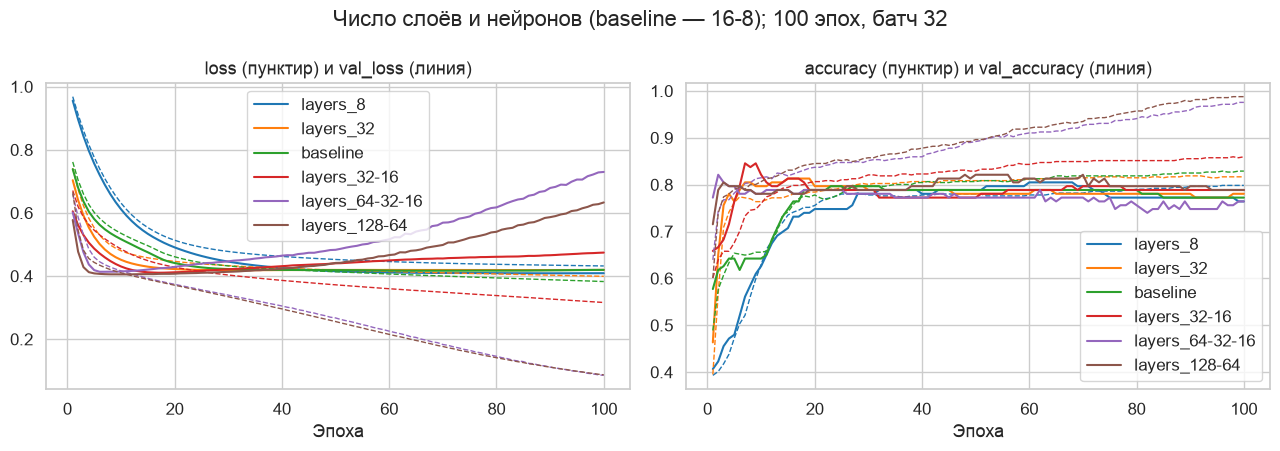

,Запуск,Скрытые слои,Активация,Параметров,Эпох,Батч,loss,accuracy,auc,val_loss,val_accuracy,val_auc,Мин. val_loss,Эпоха мин. val_loss
9,layers_8,8,relu,81,100,32,0.4316,0.7984,0.8656,0.4090,0.7642,0.8821,0.4087,91
10,layers_32,32,relu,321,100,32,0.3980,0.8167,0.8897,0.4194,0.7805,0.8701,0.4185,34
11,layers_32-16,32-16,relu,833,100,32,0.3130,0.8656,0.9347,0.4743,0.7886,0.8478,0.4105,17
12,layers_64-32-16,64-32-16,relu,3201,100,32,0.0789,0.9817,0.9991,0.7297,0.7642,0.8189,0.4135,6
13,layers_128-64,128-64,relu,9473,100,32,0.0809,0.9878,0.9996,0.6331,0.7886,0.8247,0.4053,10


In [36]:
for layers in [(8,), (32,), (32, 16), (64, 32, 16), (128, 64)]:
    run_experiment('layers_' + '-'.join(map(str, layers)), hidden_layers=layers)
plot_runs(['layers_8', 'layers_32', 'baseline', 'layers_32-16', 'layers_64-32-16', 'layers_128-64'],
          'Число слоёв и нейронов (baseline — 16-8); 100 эпох, батч 32', 'nn_layers.png')
display(pd.DataFrame(nn_rows).round(4).tail(5))

Чем больше параметров, тем сильнее переобучение. Сети с одним слоем из 8 и из 32 нейронов и базовая 16-8 к 100-й эпохе имеют val_loss 0,409, 0,419 и 0,420. У сети 32-16 минимум val_loss (0,410) уже на 17-й эпохе, а к 100-й — 0,474. Сети 64-32-16 (3201 параметр) и 128-64 (9473 параметра) почти «выучили» обучающую часть (accuracy 0,982 и 0,988, loss 0,079 и 0,081), но val_loss у них вырос до 0,730 и 0,633 — минимумы были на 6-й и 10-й эпохах. На графике это расходящиеся «ножницы»: пунктир (обучение) уходит вниз, сплошная линия (валидация) — вверх. Для 491 обучающего объекта достаточно маленькой сети; наименьший итоговый val_loss — у сети с одним скрытым слоем из 8 нейронов.

### 6.5. Функции активации

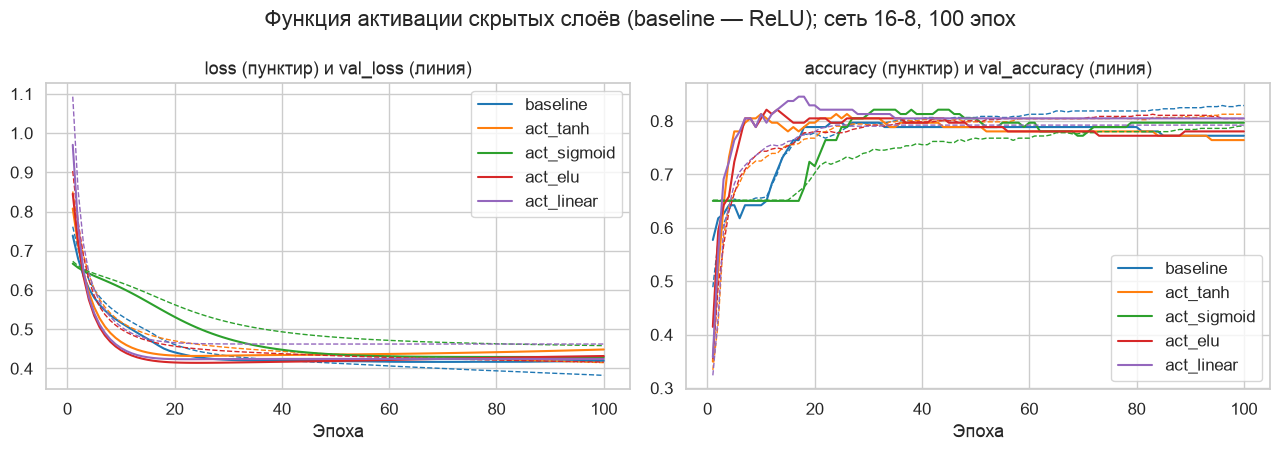

,Запуск,Скрытые слои,Активация,Параметров,Эпох,Батч,loss,accuracy,auc,val_loss,val_accuracy,val_auc,Мин. val_loss,Эпоха мин. val_loss
14,act_tanh,16-8,tanh,289,100,32,0.4139,0.8147,0.8752,0.4484,0.7642,0.8551,0.4320,24
15,act_sigmoid,16-8,sigmoid,289,100,32,0.4579,0.7902,0.8477,0.4290,0.7967,0.8751,0.4290,100
16,act_elu,16-8,elu,289,100,32,0.4152,0.8065,0.8759,0.4318,0.7805,0.8654,0.4144,24
17,act_linear,16-8,linear,289,100,32,0.4614,0.7923,0.8435,0.4244,0.8049,0.8712,0.4236,23


In [37]:
for activation in ['tanh', 'sigmoid', 'elu', 'linear']:
    run_experiment('act_' + activation, activation=activation)
plot_runs(['baseline', 'act_tanh', 'act_sigmoid', 'act_elu', 'act_linear'],
          'Функция активации скрытых слоёв (baseline — ReLU); сеть 16-8, 100 эпох', 'nn_activation.png')
display(pd.DataFrame(nn_rows).round(4).tail(4))

При архитектуре 16-8 итоговый val_loss: ReLU — 0,420, linear — 0,424, sigmoid — 0,429, ELU — 0,432, tanh — 0,448. У tanh и ELU минимум val_loss на 24-й эпохе, дальше — переобучение; у сигмоиды val_loss убывал все 100 эпох (минимум на 100-й), то есть она обучается медленнее: производная сигмоиды не больше 0,25, и градиенты при прохождении слоёв уменьшаются. Сеть с линейной активацией скрытых слоёв эквивалентна логистической регрессии (композиция линейных слоёв линейна, на выходе — сигмоида), и она почти не уступает ReLU: val_loss 0,424 против 0,420, а val_accuracy 0,805 — наибольшая среди всех вариантов. Это согласуется с тем, что линейный SVM не уступил RBF: граница между классами в этих данных близка к линейной.

### 6.6. Ранняя остановка (EarlyStopping)

In [38]:
history_es = run_experiment('early_stopping', epochs=400, early_stopping=True)
print('Обучение остановлено после эпохи', len(history_es['loss']),
      '; восстановлены веса эпохи с минимальным val_loss:', int(np.argmin(history_es['val_loss'])) + 1)
display(pd.DataFrame(nn_rows).round(4).tail(1))

Обучение остановлено после эпохи 90 ; восстановлены веса эпохи с минимальным val_loss: 70


,Запуск,Скрытые слои,Активация,Параметров,Эпох,Батч,loss,accuracy,auc,val_loss,val_accuracy,val_auc,Мин. val_loss,Эпоха мин. val_loss
18,early_stopping,16-8,relu,289,90,32,0.3989,0.8187,0.8878,0.4168,0.7886,0.8741,0.4168,70


`EarlyStopping` следит за val_loss: если он не улучшается 20 эпох подряд (`patience=20`), обучение останавливается, а веса возвращаются к лучшей эпохе (`restore_best_weights=True`). Из 400 разрешённых эпох обучение остановилось после 90-й, восстановлены веса 70-й эпохи; val_loss 0,417, val_accuracy 0,789, val_auc 0,874 — как в минимуме кривой из эксперимента с числом эпох. Ранняя остановка сама подбирает число эпох и защищает от переобучения.

### 6.7. Сводка экспериментов и проверка на тестовой выборке

In [39]:
nn_table = pd.DataFrame(nn_rows).set_index('Запуск')
nn_table.to_csv('Результаты/nn_experiments.csv')
display(nn_table.sort_values('val_loss').round(4))
best_run = nn_table['val_loss'].idxmin()
print('Наименьший val_loss у запуска:', best_run)
summary['nn_best_run'] = best_run

,Скрытые слои,Активация,Параметров,Эпох,Батч,loss,accuracy,auc,val_loss,val_accuracy,val_auc,Мин. val_loss,Эпоха мин. val_loss
Запуск,,,,,,,,,,,,,
layers_8,8,relu,81,100,32,0.4316,0.7984,0.8656,0.4090,0.7642,0.8821,0.4087,91
batch_64,16-8,relu,289,100,64,0.4004,0.8106,0.8867,0.4162,0.7886,0.8718,0.4162,95
early_stopping,16-8,relu,289,90,32,0.3989,0.8187,0.8878,0.4168,0.7886,0.8741,0.4168,70
batch_128,16-8,relu,289,100,128,0.4195,0.8086,0.8760,0.4176,0.7886,0.8711,0.4176,100
epochs_50,16-8,relu,289,50,32,0.4122,0.8086,0.8801,0.4187,0.7886,0.8706,0.4187,50
layers_32,32,relu,321,100,32,0.3980,0.8167,0.8897,0.4194,0.7805,0.8701,0.4185,34
baseline,16-8,relu,289,100,32,0.3813,0.8269,0.8981,0.4196,0.7724,0.8744,0.4168,70
act_linear,16-8,linear,289,100,32,0.4614,0.7923,0.8435,0.4244,0.8049,0.8712,0.4236,23
batch_16,16-8,relu,289,100,16,0.3588,0.8452,0.9117,0.4280,0.7642,0.8703,0.4168,51


Наименьший val_loss у запуска: layers_8


Таблица всех 19 запусков отсортирована по итоговому val_loss. Наименьший val_loss (0,409) у сети с одним скрытым слоем из 8 нейронов; близки батч 64 (0,416), ранняя остановка (0,417), батч 128 (0,418), 50 эпох (0,419) и базовая сеть (0,420). Хуже всего — переобученные конфигурации: 400 эпох (0,559), 128-64 (0,633) и 64-32-16 (0,730). Различия между первыми десятью запусками (0,409–0,429) малы по сравнению с отрывом переобученных.

In [40]:
nn_test = {}
for name in ['baseline', best_run]:
    proba = nn_models[name](X_test_s).numpy().ravel()
    nn_test[name] = test_metrics(y_test, (proba >= 0.5).astype(int), proba)
nn_test = pd.DataFrame(nn_test).T
display(nn_test.round(3))
nn_test.to_csv('Результаты/nn_test.csv')

,accuracy,precision,recall,f1,roc_auc
baseline,0.727,0.625,0.556,0.588,0.819
layers_8,0.714,0.593,0.593,0.593,0.799


На тестовой выборке базовая сеть: accuracy 0,727, precision 0,625, recall 0,556, F1 0,588, ROC-AUC 0,819; сеть с одним слоем из 8 нейронов, лучшая по val_loss, — accuracy 0,714, recall 0,593, F1 0,593, ROC-AUC 0,799. Небольшое преимущество на валидационной части (val_loss 0,409 против 0,420 на 123 объектах) на тест не перенеслось. Обе сети обучены на 491 объекте; в разделе 7 сети обучаются на всей обучающей выборке (614 объектов).

## 7. Сеть с 5-кратной кросс-валидацией и Grid Search (дополнительное задание)

Вторая сеть задаётся функцией `build_model(architecture, learning_rate)`: скрытые слои ReLU с числами нейронов из кортежа `architecture`, выход — сигмоида, потери — бинарная кросс-энтропия, оптимизатор Adam с заданной скоростью обучения. Grid Search: 3 скорости обучения (0,01; 0,001; 0,0001) × 3 архитектуры — (16,), (32, 16), (64, 32, 16) — итого 9 конфигураций. Каждая конфигурация оценивается 5-кратной стратифицированной кросс-валидацией на обучающей выборке (те же фолды `cv`, что у методов scikit-learn): 9 × 5 = 45 обучений по 100 эпох с батчем 32. В каждом фолде предобработка (медиана + стандартизация) обучается только на обучающей части фолда, а loss и accuracy на обучающей и валидационной частях записываются в TensorBoard: `logs/gridsearch/<конфигурация>/fold_<k>`. Критерий выбора — средняя accuracy на валидационных фолдах (её требует задание); дополнительно считаются средний val_loss и ROC-AUC (функцией `roc_auc_score`, как у методов scikit-learn).

In [41]:
GS_EPOCHS = 100
GS_BATCH = 32

def build_model(architecture, learning_rate):
    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=(X_train.shape[1],)))
    for units in architecture:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

def cross_validate_network(architecture, learning_rate, run_name):
    fold_acc, fold_loss, fold_auc, curves = [], [], [], []
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):
        prep = make_prep()
        X_fold_train = prep.fit_transform(X_train.iloc[train_idx])
        X_fold_val = prep.transform(X_train.iloc[val_idx])
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        tf.keras.utils.set_random_seed(RANDOM_STATE)
        model = build_model(architecture, learning_rate)
        log_dir = os.path.join('logs', 'gridsearch', run_name, 'fold_' + str(fold))
        history = model.fit(X_fold_train, y_fold_train, validation_data=(X_fold_val, y_fold_val),
                            epochs=GS_EPOCHS, batch_size=GS_BATCH, verbose=0,
                            callbacks=[tf.keras.callbacks.TensorBoard(log_dir=log_dir)])
        loss, acc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
        fold_loss.append(loss)
        fold_acc.append(acc)
        fold_auc.append(roc_auc_score(y_fold_val, model(X_fold_val).numpy().ravel()))
        curves.append(history.history['val_accuracy'])
    return fold_acc, fold_loss, fold_auc, np.mean(curves, axis=0)

`cross_validate_network` для одной конфигурации проходит по тем же 5 фолдам `cv`: в каждом фолде создаётся новая предобработка (обучается только на обучающей части фолда) и новая сеть с одинаковыми начальными весами (seed перед созданием); сеть обучается 100 эпох и оценивается на валидационной части фолда — loss и accuracy функцией `evaluate`, ROC-AUC функцией `roc_auc_score`. Лог каждого фолда пишется в отдельную папку `logs/gridsearch/<конфигурация>/fold_<k>`, где TensorBoard показывает loss и accuracy на обучающей (train) и валидационной (validation) частях по эпохам.

In [42]:
LEARNING_RATES = [0.01, 0.001, 0.0001]
ARCHITECTURES = [(16,), (32, 16), (64, 32, 16)]

gs_rows, gs_folds, gs_curves = [], {}, {}
for lr in LEARNING_RATES:
    for arch in ARCHITECTURES:
        arch_name = '-'.join(map(str, arch))
        run_name = 'lr' + str(lr) + '_arch' + arch_name
        acc, loss, auc, curve = cross_validate_network(arch, lr, run_name)
        gs_rows.append({'Конфигурация': run_name, 'learning_rate': lr, 'Архитектура': arch_name,
                        'Параметров': build_model(arch, lr).count_params(),
                        'accuracy': np.mean(acc), 'accuracy, ст. откл.': np.std(acc),
                        'val_loss': np.mean(loss), 'ROC-AUC': np.mean(auc), 'ROC-AUC, ст. откл.': np.std(auc)})
        gs_folds[run_name] = acc
        gs_curves[run_name] = curve

gs_table = pd.DataFrame(gs_rows).set_index('Конфигурация')
display(gs_table.round(4))
gs_table.to_csv('Результаты/gs_results.csv')
gs_fold_table = pd.DataFrame(gs_folds, index=['fold_' + str(k) for k in range(1, 6)]).T
gs_fold_table.to_csv('Результаты/gs_folds.csv')
display(gs_fold_table.round(3))

,learning_rate,Архитектура,Параметров,accuracy,"accuracy, ст. откл.",val_loss,ROC-AUC,"ROC-AUC, ст. откл."
Конфигурация,,,,,,,,
lr0.01_arch16,0.0100,16,161,0.7671,0.0277,0.5971,0.8082,0.0443
lr0.01_arch32-16,0.0100,32-16,833,0.6954,0.0389,2.4356,0.7374,0.0528
lr0.01_arch64-32-16,0.0100,64-32-16,3201,0.7312,0.0432,2.8063,0.7724,0.0501
lr0.001_arch16,0.0010,16,161,0.7834,0.0145,0.4549,0.8524,0.0252
lr0.001_arch32-16,0.0010,32-16,833,0.7622,0.0200,0.5371,0.8224,0.0348
lr0.001_arch64-32-16,0.0010,64-32-16,3201,0.7296,0.0476,1.1725,0.7639,0.0524
lr0.0001_arch16,0.0001,16,161,0.7216,0.0232,0.5605,0.7463,0.0312
lr0.0001_arch32-16,0.0001,32-16,833,0.7574,0.0266,0.4893,0.8259,0.0157
lr0.0001_arch64-32-16,0.0001,64-32-16,3201,0.7883,0.0148,0.4522,0.8542,0.0201


,fold_1,fold_2,fold_3,fold_4,fold_5
lr0.01_arch16,0.797,0.764,0.797,0.724,0.754
lr0.01_arch32-16,0.740,0.691,0.740,0.650,0.656
lr0.01_arch64-32-16,0.715,0.732,0.813,0.707,0.689
lr0.001_arch16,0.789,0.789,0.805,0.764,0.770
lr0.001_arch32-16,0.772,0.748,0.789,0.732,0.770
lr0.001_arch64-32-16,0.756,0.748,0.780,0.642,0.721
lr0.0001_arch16,0.732,0.715,0.724,0.683,0.754
lr0.0001_arch32-16,0.724,0.748,0.797,0.740,0.779
lr0.0001_arch64-32-16,0.805,0.764,0.797,0.797,0.779


Средняя accuracy по 5 фолдам меняется от 0,695 (lr = 0,01, 32-16) до 0,788 (lr = 0,0001, 64-32-16). Лучшие конфигурации: lr = 0,0001 с архитектурой 64-32-16 — 0,788 ± 0,015 и lr = 0,001 с архитектурой 16 — 0,783 ± 0,014; у них же наибольший ROC-AUC (0,854 и 0,852) и наименьший val_loss (0,452 и 0,455). При lr = 0,01 сети 32-16 и 64-32-16 сильно переобучаются: val_loss 2,44 и 2,81 (сеть даёт уверенные неверные ответы), accuracy 0,695 и 0,731. При lr = 0,0001 маленькая сеть 16 за 100 эпох не успевает обучиться (0,722). Стандартное отклонение по фолдам (0,014–0,048) сопоставимо с различиями соседних конфигураций. Вторая таблица — accuracy в каждом фолде: например, у lr = 0,001 с 64-32-16 четвёртый фолд дал 0,642 при 0,721–0,780 в остальных.

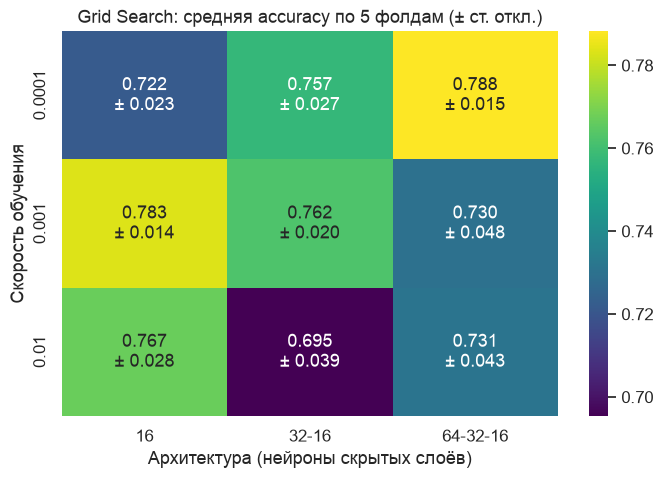

In [43]:
mean_acc = gs_table.pivot_table(index='learning_rate', columns='Архитектура', values='accuracy')
std_acc = gs_table.pivot_table(index='learning_rate', columns='Архитектура', values='accuracy, ст. откл.')
labels = mean_acc.map(lambda v: format(v, '.3f')) + '\n± ' + std_acc.map(lambda v: format(v, '.3f'))
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(mean_acc, annot=labels, fmt='', cmap='viridis', ax=ax)
ax.set_title('Grid Search: средняя accuracy по 5 фолдам (± ст. откл.)')
ax.set_xlabel('Архитектура (нейроны скрытых слоёв)')
ax.set_ylabel('Скорость обучения')
fig.savefig('Рисунки/gs_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

Тепловая карта показывает взаимодействие скорости обучения и размера сети при фиксированных 100 эпохах: для маленькой сети (16) лучшая скорость 0,001 (0,783), для средней (32-16) — тоже 0,001 (0,762), для большой (64-32-16) — 0,0001 (0,788). Чем больше сеть, тем меньшая скорость нужна, чтобы за 100 эпох не переобучиться, а слишком малая скорость для маленькой сети ведёт к недообучению. Поэтому скорость обучения нельзя выбирать в отрыве от архитектуры и числа эпох.

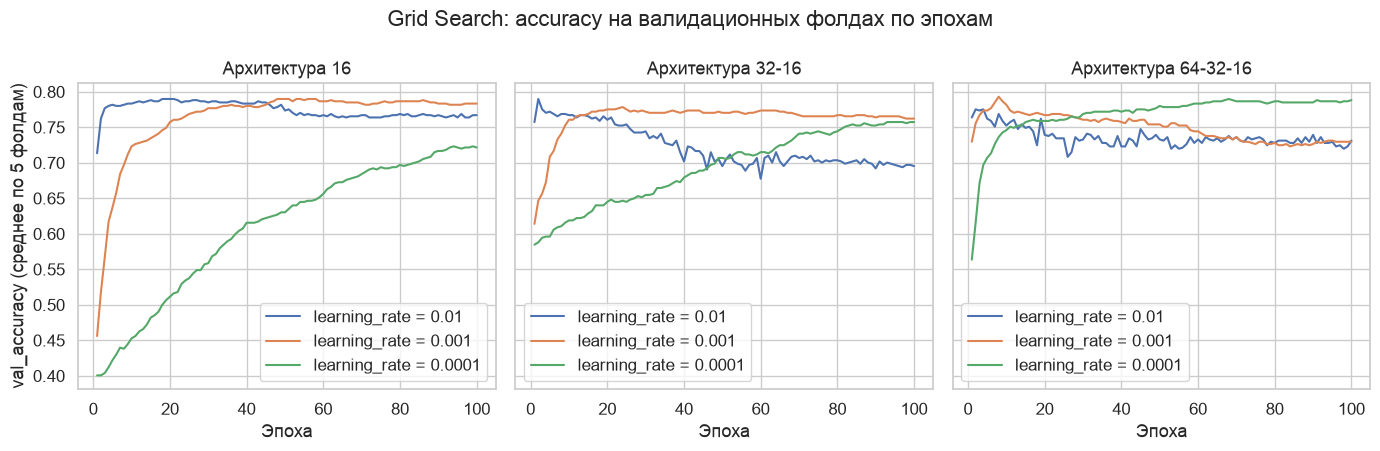

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), sharey=True)
for ax, arch in zip(axes, ARCHITECTURES):
    arch_name = '-'.join(map(str, arch))
    for lr in LEARNING_RATES:
        curve = gs_curves['lr' + str(lr) + '_arch' + arch_name]
        ax.plot(range(1, GS_EPOCHS + 1), curve, label='learning_rate = ' + str(lr))
    ax.set_title('Архитектура ' + arch_name)
    ax.set_xlabel('Эпоха')
    ax.legend()
axes[0].set_ylabel('val_accuracy (среднее по 5 фолдам)')
fig.suptitle('Grid Search: accuracy на валидационных фолдах по эпохам')
fig.tight_layout()
fig.savefig('Рисунки/gs_curves.png', dpi=200, bbox_inches='tight')
plt.show()

Средняя по фолдам val_accuracy по эпохам объясняет таблицу. При lr = 0,01 accuracy достигает максимума за первые эпохи и затем снижается, особенно у сетей 32-16 и 64-32-16 (переобучение). При lr = 0,0001 кривые растут медленно: у сети 16 рост к 100-й эпохе ещё не закончился (недообучение), а у 64-32-16 после 60-й эпохи кривая выходит на плато около 0,79. При lr = 0,001 сеть 16 держится около 0,78–0,79, а 64-32-16 достигает максимума около 8-й эпохи и затем теряет accuracy. Те же кривые по каждому фолду отдельно доступны в TensorBoard.

In [45]:
base_acc, base_loss, base_auc, base_curve = cross_validate_network((16, 8), 0.001, 'baseline_lr0.001_arch16-8')
dummy_cv = cross_validate(DummyClassifier(strategy='most_frequent'), X_train, y_train, cv=cv,
                          scoring='accuracy')['test_score']
best_config = gs_table['accuracy'].idxmax()
best_lr = gs_table.loc[best_config, 'learning_rate']
best_arch = tuple(int(units) for units in gs_table.loc[best_config, 'Архитектура'].split('-'))
print('Лучшая конфигурация:', best_config)
print('Baseline (сеть п. 6, 16-8, lr = 0.001): accuracy (CV) =', round(np.mean(base_acc), 4),
      '±', round(np.std(base_acc), 4))
print('«Всегда класс 0»: accuracy (CV) =', round(dummy_cv.mean(), 4))
summary['gs_best_config'] = best_config

Лучшая конфигурация: lr0.0001_arch64-32-16
Baseline (сеть п. 6, 16-8, lr = 0.001): accuracy (CV) = 0.7785 ± 0.0117
«Всегда класс 0»: accuracy (CV) = 0.6515


Для честного сравнения baseline — сеть из п. 6 с исходными параметрами (16-8, ReLU, lr = 0,001, 100 эпох, батч 32) — прогнана через ту же кросс-валидацию: accuracy 0,7785 ± 0,0117. Лучшая конфигурация Grid Search (lr = 0,0001, 64-32-16) — 0,7883 ± 0,0148, то есть выше на 0,010, что меньше стандартного отклонения по фолдам. Тривиальная модель «всегда класс 0» даёт 0,6515.

In [46]:
full_prep = make_prep()
X_train_full_s = full_prep.fit_transform(X_train)
X_test_full_s = full_prep.transform(X_test)

def fit_on_full_train(architecture, learning_rate, run_name):
    tf.keras.utils.set_random_seed(RANDOM_STATE)
    model = build_model(architecture, learning_rate)
    model.fit(X_train_full_s, y_train, epochs=GS_EPOCHS, batch_size=GS_BATCH, verbose=0,
              callbacks=[tf.keras.callbacks.TensorBoard(log_dir=os.path.join('logs', 'final', run_name))])
    return model

NAME_GS = 'Сеть ' + gs_table.loc[best_config, 'Архитектура'] + ', lr = ' + str(best_lr) + ' (Grid Search)'
NAME_BASE = 'Сеть 16-8, lr = 0.001 (baseline)'
NAME_DUMMY = '«Всегда класс 0»'
final_nets = {NAME_GS: fit_on_full_train(best_arch, best_lr, 'best_' + best_config),
              NAME_BASE: fit_on_full_train((16, 8), 0.001, 'baseline')}
dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)

nn_scores = {name: model(X_test_full_s).numpy().ravel() for name, model in final_nets.items()}
nn_scores[NAME_DUMMY] = dummy.predict_proba(X_test)[:, 1]
gs_final = pd.DataFrame({name: test_metrics(y_test, (score >= 0.5).astype(int), score)
                         for name, score in nn_scores.items()}).T
gs_final['accuracy (CV), среднее'] = [gs_table.loc[best_config, 'accuracy'], np.mean(base_acc), dummy_cv.mean()]
gs_final['accuracy (CV), ст. откл.'] = [gs_table.loc[best_config, 'accuracy, ст. откл.'], np.std(base_acc), dummy_cv.std()]
display(gs_final.round(4))
gs_final.to_csv('Результаты/gs_final.csv')

,accuracy,precision,recall,f1,roc_auc,"accuracy (CV), среднее","accuracy (CV), ст. откл."
"Сеть 64-32-16, lr = 0.0001 (Grid Search)",0.7208,0.6122,0.5556,0.5825,0.8189,0.7883,0.0148
"Сеть 16-8, lr = 0.001 (baseline)",0.7403,0.6346,0.6111,0.6226,0.8137,0.7785,0.0117
«Всегда класс 0»,0.6494,0.0000,0.0000,0.0000,0.5000,0.6515,0.0021


Обе сети обучены на всей обучающей выборке (614 объектов, предобработка обучена на ней же) и проверены на тесте. Accuracy на тесте: лучшая по Grid Search сеть — 0,721, baseline — 0,740, «всегда класс 0» — 0,649. Эффект настройки: по кросс-валидации прирост accuracy +0,010 (в пределах разброса), на тесте он не подтвердился (−0,019, то есть 3 объекта из 154); по ROC-AUC на тесте настроенная сеть чуть лучше (0,819 против 0,814). Обе сети заметно лучше тривиальной модели (на 0,07–0,09 по accuracy). Главная польза Grid Search здесь — не прирост над baseline, а выявление неудачных сочетаний скорости обучения и архитектуры (accuracy до 0,695), при которых сеть переобучается или недообучается.

## 8. Сравнительный анализ

In [47]:
final_table = pd.concat([test_table, gs_final[list(metric_names)].loc[[NAME_BASE, NAME_GS, NAME_DUMMY]]])
display(final_table.round(3))
final_table.to_csv('Результаты/final_test.csv')

,accuracy,precision,recall,f1,roc_auc
Наивный Байес,0.701,0.567,0.630,0.596,0.764
Дерево решений,0.779,0.778,0.519,0.622,0.838
LDA,0.701,0.587,0.500,0.540,0.808
SVM,0.695,0.578,0.481,0.525,0.817
kNN,0.721,0.649,0.444,0.527,0.800
"Сеть 16-8, lr = 0.001 (baseline)",0.740,0.635,0.611,0.623,0.814
"Сеть 64-32-16, lr = 0.0001 (Grid Search)",0.721,0.612,0.556,0.583,0.819
«Всегда класс 0»,0.649,0.000,0.000,0.000,0.500


Итоговая таблица — все методы и сети на одной тестовой выборке; сети здесь обучены на всей обучающей выборке, как и методы scikit-learn. Accuracy: лучшая у дерева решений (0,779), затем baseline-сеть (0,740); у остальных 0,695–0,721; у тривиальной модели — 0,649. ROC-AUC: дерево — 0,838, сеть Grid Search — 0,819, SVM — 0,817, baseline-сеть — 0,814, LDA — 0,808, kNN — 0,800, наивный Байес — 0,764. Recall: наивный Байес — 0,630, baseline-сеть — 0,611, сеть Grid Search — 0,556, у остальных 0,444–0,519. F1: baseline-сеть — 0,623, дерево — 0,622.

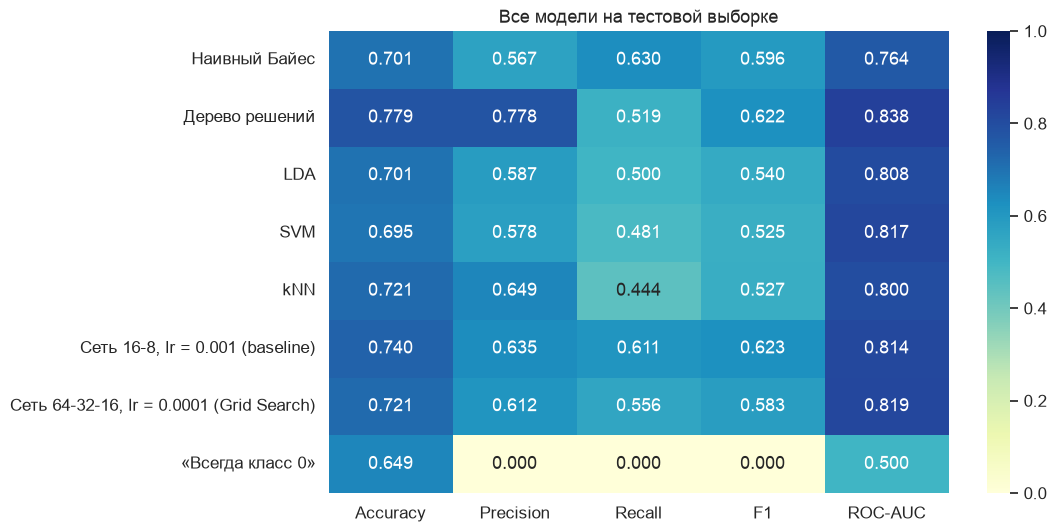

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(final_table.rename(columns=metric_names), annot=True, fmt='.3f', cmap='YlGnBu',
            vmin=0, vmax=1, ax=ax)
ax.set_title('Все модели на тестовой выборке')
fig.savefig('Рисунки/final_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

Тепловая карта показывает ту же таблицу цветом (чем темнее ячейка, тем выше значение). Самый тёмный столбец — ROC-AUC, самые светлые — recall и F1 при пороге 0,5. Ни одна модель не лидирует по всем метрикам сразу.

In [49]:
test_scores = {name: positive_scores(model, X_test) for name, model in best_models.items()}
test_scores.update({name: nn_scores[name] for name in [NAME_BASE, NAME_GS]})

rng = np.random.RandomState(RANDOM_STATE)
boot_samples = [rng.randint(0, len(y_test), len(y_test)) for _ in range(1000)]
y_test_array = y_test.to_numpy()
boot_low, boot_high = {}, {}
for name, score in test_scores.items():
    aucs = [roc_auc_score(y_test_array[idx], score[idx]) for idx in boot_samples]
    boot_low[name], boot_high[name] = np.percentile(aucs, [2.5, 97.5])

cv_auc = tuning['ROC-AUC после настройки'].to_dict()
cv_std = tuning['Ст. откл. после настройки'].to_dict()
cv_auc[NAME_BASE], cv_std[NAME_BASE] = np.mean(base_auc), np.std(base_auc)
cv_auc[NAME_GS] = gs_table.loc[best_config, 'ROC-AUC']
cv_std[NAME_GS] = gs_table.loc[best_config, 'ROC-AUC, ст. откл.']
cv_vs_test = pd.DataFrame({'ROC-AUC (CV), среднее': cv_auc, 'ROC-AUC (CV), ст. откл.': cv_std,
                           'ROC-AUC (test)': final_table['roc_auc'].drop(NAME_DUMMY),
                           'test: 2,5 %': boot_low, 'test: 97,5 %': boot_high})
display(cv_vs_test.round(3))
cv_vs_test.to_csv('Результаты/cv_vs_test.csv')

,"ROC-AUC (CV), среднее","ROC-AUC (CV), ст. откл.",ROC-AUC (test),"test: 2,5 %","test: 97,5 %"
Наивный Байес,0.829,0.009,0.764,0.675,0.839
Дерево решений,0.805,0.032,0.838,0.767,0.897
LDA,0.845,0.015,0.808,0.730,0.873
SVM,0.846,0.016,0.817,0.743,0.879
kNN,0.837,0.018,0.800,0.715,0.865
"Сеть 16-8, lr = 0.001 (baseline)",0.850,0.019,0.814,0.738,0.877
"Сеть 64-32-16, lr = 0.0001 (Grid Search)",0.854,0.020,0.819,0.747,0.883


Чтобы оценить надёжность различий на тесте, ROC-AUC на тесте дополнен 95-процентным бутстрэп-интервалом: 1000 раз из 154 тестовых объектов случайно с возвращением выбирались 154, по каждой такой выборке пересчитывался ROC-AUC, а 2,5-й и 97,5-й процентили дали границы интервала. Ширина интервалов — 0,13–0,16, и все они перекрываются: например, у дерева 0,838 [0,767; 0,897], у наивного Байеса 0,764 [0,675; 0,839]. Значит, по одной тестовой выборке из 154 объектов нельзя уверенно утверждать, что одна модель лучше другой. Кросс-валидация на 614 объектах устойчивее: по ней лучшие — сети (0,854 и 0,850), SVM (0,846) и LDA (0,845), далее kNN (0,837) и наивный Байес (0,829), а дерево последнее (0,805) и самое нестабильное (стандартное отклонение 0,032). Высокий результат дерева на тесте кросс-валидацией не подтверждается.

In [50]:
chosen = 'LDA'
proba_cv = cross_val_predict(best_models[chosen], X_train, y_train, cv=cv, method='predict_proba')[:, 1]
proba_test = best_models[chosen].predict_proba(X_test)[:, 1]
threshold_rows = []
for threshold in [0.5, 0.4, 0.3, 0.2]:
    pred_cv = (proba_cv >= threshold).astype(int)
    pred_test = (proba_test >= threshold).astype(int)
    threshold_rows.append({'Порог': threshold,
                           'recall (CV)': recall_score(y_train, pred_cv),
                           'precision (CV)': precision_score(y_train, pred_cv),
                           'recall (test)': recall_score(y_test, pred_test),
                           'precision (test)': precision_score(y_test, pred_test),
                           'Пропущено больных (test)': int(((pred_test == 0) & (y_test == 1)).sum())})
thresholds = pd.DataFrame(threshold_rows).set_index('Порог')
display(thresholds.round(3))
thresholds.to_csv('Результаты/thresholds.csv')

,recall (CV),precision (CV),recall (test),precision (test),Пропущено больных (test)
Порог,,,,,
0.5,0.584,0.744,0.500,0.587,27
0.4,0.673,0.692,0.648,0.614,19
0.3,0.738,0.610,0.759,0.577,13
0.2,0.864,0.541,0.889,0.558,6


При скрининге цель — не пропустить больных, поэтому кроме accuracy важен recall. При пороге 0,5 LDA находит на тесте только половину больных (recall 0,500, пропущено 27 из 54). Порог выбирается по обучающей выборке: вероятности получены функцией `cross_val_predict` (каждый объект train оценён моделью, не видевшей его при обучении). При пороге 0,3 recall на кросс-валидации 0,738 (precision 0,610), на тесте — 0,759 (precision 0,577, пропущено 13 больных); при пороге 0,2 recall 0,864 на кросс-валидации и 0,889 на тесте (пропущено 6) при precision 0,541 и 0,558. Значения на кросс-валидации и на тесте близки, то есть выбранный по train порог переносится на новые данные. Рост recall оплачивается снижением precision: больше здоровых получают ложную тревогу. Какой порог нужен на практике, по данным определить нельзя: это зависит от того, насколько пропуск больного «дороже» ложной тревоги.

In [51]:
summary['best_params'] = {name: params_to_text(g.best_params_) for name, g in grids.items()}
summary['tree_depth'], summary['tree_leaves'] = int(best_tree.get_depth()), int(best_tree.get_n_leaves())
summary['epochs_prefix_equal'] = bool(same_start)
summary['es_epochs'] = len(history_es['loss'])
summary['es_best_epoch'] = int(np.argmin(history_es['val_loss'])) + 1
summary['gs_best_name'], summary['gs_base_name'] = NAME_GS, NAME_BASE
summary['threshold_model'] = chosen
with open('Результаты/summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=1)
print(json.dumps(summary, ensure_ascii=False, indent=1))

{
 "n_rows": 768,
 "n_cols": 9,
 "duplicates": 0,
 "skin_and_insulin_zero": 227,
 "nn_train_size": 491,
 "nn_val_size": 123,
 "nn_best_run": "layers_8",
 "gs_best_config": "lr0.0001_arch64-32-16",
 "best_params": {
  "Наивный Байес": "var_smoothing=1e-06",
  "Дерево решений": "criterion=entropy, max_depth=5, min_samples_leaf=30",
  "LDA": "shrinkage=0.15, solver=lsqr",
  "SVM": "C=100, gamma=0.001, kernel=rbf",
  "kNN": "n_neighbors=84, p=2, weights=distance"
 },
 "tree_depth": 5,
 "tree_leaves": 11,
 "epochs_prefix_equal": true,
 "es_epochs": 90,
 "es_best_epoch": 70,
 "gs_best_name": "Сеть 64-32-16, lr = 0.0001 (Grid Search)",
 "gs_base_name": "Сеть 16-8, lr = 0.001 (baseline)",
 "threshold_model": "LDA"
}


Ключевые числа (размеры выборок, лучшие параметры, сведения о дереве и ранней остановке, названия лучших сетей) сохранены в `Результаты/summary.json`, таблицы всех разделов — в CSV-файлах папки `Результаты`, рисунки — в папке `Рисунки`.

## Выводы

1. **Данные.** 768 пациенток, 8 числовых признаков, классы 65,1 % и 34,9 %. Физически невозможные нули (у Insulin — 48,7 % строк, у SkinThickness — 29,6 %) обработаны как пропуски и заполнены медианой внутри `Pipeline`; стандартизация применена для LDA, SVM, kNN и нейросетей. Разбиение 614/154 со стратификацией, seed 42 везде, результаты воспроизводимы.
2. **Методы.** С параметрами по умолчанию ROC-AUC на кросс-валидации — от 0,651 (дерево) до 0,843 (LDA). Из вариантов наивного Байеса для непрерывных признаков лучший GaussianNB (0,828); MultinomialNB при пороге 0,5 не находит ни одного больного.
3. **Настройка** (GridSearchCV по ROC-AUC, 5 фолдов): дерево — entropy, max_depth = 5, min_samples_leaf = 30 (0,805); kNN — k = 84, distance, p = 2 (0,837); SVM — RBF, C = 100, gamma = 0,001 (0,846); LDA — lsqr, shrinkage = 0,15 (0,845); GaussianNB — var_smoothing = $10^{-6}$ (0,829). Кривые валидации показали переобучение глубокого дерева, kNN с малым k и SVM с большими gamma и C; линейный SVM почти не уступает RBF.
4. **Тест.** Лучшие accuracy (0,779) и ROC-AUC (0,838) у дерева, наибольший recall — у наивного Байеса (0,630). Но 95-процентные бутстрэп-интервалы ROC-AUC всех моделей перекрываются (ширина 0,13–0,16), а на кросс-валидации дерево худшее (0,805 ± 0,032).
5. **Нейросеть.** Базовая 16-8 (ReLU, Adam, 100 эпох, батч 32) — val_accuracy 0,772, на тесте accuracy 0,727 и ROC-AUC 0,819. Рост числа эпох (200–400) и размера сети (64-32-16, 128-64) приводит к переобучению, которое видно по расходящимся loss и val_loss; ранняя остановка выбрала веса 70-й эпохи; линейная активация почти не уступает ReLU.
6. **Дополнительное задание.** Grid Search 3 × 3 с 5-кратной кросс-валидацией выбрал lr = 0,0001 и архитектуру 64-32-16 (accuracy 0,788 ± 0,015 против 0,779 ± 0,012 у baseline); на тесте 0,721 против 0,740 у baseline и 0,649 у «всегда класс 0». Прирост от настройки не превышает разброса оценок, зато Grid Search показал неудачные сочетания параметров (accuracy до 0,695).
7. **Лучший подход.** Для этого набора лучше всего работают модели с линейной или близкой к линейной границей: LDA, SVM и небольшая нейросеть дают одинаковое в пределах погрешности качество (ROC-AUC 0,845–0,854 на кросс-валидации и 0,808–0,819 на тесте). Для практического применения предпочтительна LDA: она проста, почти не зависит от гиперпараметров (0,843 уже по умолчанию) и даёт вероятности, по которым порог выбирается под задачу; при пороге 0,3 recall на тесте 0,759 вместо 0,500 при пороге 0,5.